# Synthetic dermatology miRNA case study

This notebook shows a complete clinical biomarker workflow with simulated qPCR and dermatology data.

> **Synthetic data only**
>
> Every participant, measurement, association, p-value, confidence interval, and model result in this notebook is artificial. The data were generated from random distributions for teaching and portfolio use. They are not derived from a real patient, thesis dataset, hospital record, or clinical study. The results have no diagnostic or medical meaning.

The notebook covers data generation, quality checks, demographic summaries, clinical descriptions, ΔCq analysis, multiple testing, subgroup analysis, adjusted association models, cross-validated ROC analysis, normalization sensitivity, power planning, and co-expression analysis.

## What this case study is designed to show

- A clear separation between protected clinical work and a public teaching example
- Reproducible random data generation with a fixed seed
- Correct interpretation of ΔCq
- Reference-gene stability checks before biological interpretation
- Effect sizes and confidence intervals alongside p-values
- Separate confirmatory and exploratory test families
- Association language for case-control models
- Cross-validated discrimination estimates
- A correct direct comparison of two independent correlation coefficients

The simulated sample is larger than the source teaching scenario. It includes 180 synthetic acne records and 140 synthetic control records.

In [1]:
from pathlib import Path
import json
import platform
import shutil
import warnings

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.power import TTestIndPower
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.formula.api as smf
import statsmodels.api as sm

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 20260915
rng = np.random.default_rng(SEED)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"
TABLE_DIR = PROJECT_ROOT / "tables"
for folder in (DATA_DIR, FIGURE_DIR, TABLE_DIR):
    folder.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:0.3f}")

print("Synthetic analysis seed", SEED)
print("Python", platform.python_version())

Synthetic analysis seed 20260915
Python 3.11.15


## Helper functions

The primary comparison uses the Mann-Whitney U test and rank-biserial correlation. Bootstrap intervals describe uncertainty without relying on a normal approximation. Benjamini-Hochberg correction is applied within clearly defined test families.

In [2]:
def fmt_p(value):
    if pd.isna(value):
        return "NA"
    if value < 0.001:
        return "<0.001"
    return f"{value:.3f}"


def median_iqr(values):
    values = pd.Series(values).dropna().to_numpy()
    q1, med, q3 = np.quantile(values, [0.25, 0.50, 0.75])
    return f"{med:.2f} [{q1:.2f}, {q3:.2f}]"


def rank_biserial(x, y):
    x = pd.Series(x).dropna().to_numpy()
    y = pd.Series(y).dropna().to_numpy()
    u = stats.mannwhitneyu(x, y, alternative="two-sided").statistic
    return 2 * u / (len(x) * len(y)) - 1


def bootstrap_statistic(x, y, statistic, n_boot=1500, seed=SEED):
    x = pd.Series(x).dropna().to_numpy()
    y = pd.Series(y).dropna().to_numpy()
    local_rng = np.random.default_rng(seed)
    estimates = np.empty(n_boot)
    for i in range(n_boot):
        xb = local_rng.choice(x, size=len(x), replace=True)
        yb = local_rng.choice(y, size=len(y), replace=True)
        estimates[i] = statistic(xb, yb)
    return np.quantile(estimates, [0.025, 0.975])


def compare_groups(frame, value, group="group", a="acne", b="control"):
    x = frame.loc[frame[group].eq(a), value].dropna()
    y = frame.loc[frame[group].eq(b), value].dropna()
    test = stats.mannwhitneyu(x, y, alternative="two-sided")
    effect = rank_biserial(x, y)
    ci_low, ci_high = bootstrap_statistic(
        x,
        y,
        lambda xb, yb: np.median(xb) - np.median(yb),
    )
    return {
        "variable": value,
        "acne": median_iqr(x),
        "control": median_iqr(y),
        "median_difference": np.median(x) - np.median(y),
        "difference_ci_low": ci_low,
        "difference_ci_high": ci_high,
        "rank_biserial_r": effect,
        "p_value": test.pvalue,
        "n_acne": len(x),
        "n_control": len(y),
    }


def bootstrap_auc(y_true, scores, n_boot=1500, seed=SEED):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    local_rng = np.random.default_rng(seed)
    values = []
    for _ in range(n_boot):
        idx = local_rng.integers(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) < 2:
            continue
        values.append(roc_auc_score(y_true[idx], scores[idx]))
    return np.quantile(values, [0.025, 0.975])


def threshold_metrics(y_true, scores):
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    index = np.argmax(tpr - fpr)
    cutoff = thresholds[index]
    predicted = (np.asarray(scores) >= cutoff).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predicted).ravel()
    return {
        "cutoff": cutoff,
        "sensitivity": tp / (tp + fn),
        "specificity": tn / (tn + fp),
        "PPV": tp / (tp + fp),
        "NPV": tn / (tn + fn),
        "accuracy": (tp + tn) / (tp + tn + fp + fn),
    }


def hosmer_lemeshow(y_true, probabilities, groups=10):
    frame = pd.DataFrame({"y": y_true, "p": probabilities})
    frame["bin"] = pd.qcut(frame["p"], q=groups, duplicates="drop")
    grouped = frame.groupby("bin", observed=True).agg(
        observed=("y", "sum"), expected=("p", "sum"), n=("y", "size")
    )
    expected_non_event = grouped["n"] - grouped["expected"]
    observed_non_event = grouped["n"] - grouped["observed"]
    statistic = (
        ((grouped["observed"] - grouped["expected"]) ** 2 / grouped["expected"].clip(1e-9))
        + ((observed_non_event - expected_non_event) ** 2 / expected_non_event.clip(1e-9))
    ).sum()
    degrees_freedom = max(len(grouped) - 2, 1)
    return statistic, stats.chi2.sf(statistic, degrees_freedom)

## Generate a synthetic cohort

The random generator creates broadly similar demographic distributions in both groups. Clinical variables are populated only for synthetic acne records. The target qPCR measurements are shifted by design so that the notebook has a signal to study.

A stable reference measurement is used for the main analysis. A second, deliberately unstable reference is also created. It is a teaching device that shows how a poor reference can change the apparent biological direction.

In [3]:
n_control = 140
n_acne = 180
n_total = n_control + n_acne

group = np.array(["control"] * n_control + ["acne"] * n_acne)
acne = (group == "acne").astype(int)

age = np.clip(rng.normal(24.0 - 0.5 * acne, 4.0, n_total), 18, 42)
sex_female = rng.binomial(1, 0.67 + 0.01 * acne, n_total)
bmi = np.clip(rng.normal(23.1 + 0.2 * acne, 3.0, n_total), 17, 36)
smoke = rng.binomial(1, 0.27 + 0.01 * acne, n_total)

age_onset = np.where(acne == 1, np.clip(rng.normal(16.4, 2.8, n_total), 10, age), np.nan)
disease_duration = np.where(acne == 1, np.maximum(age - age_onset, 0.25), np.nan)
gags = np.where(acne == 1, np.clip(rng.gamma(4.5, 4.0, n_total), 4, 44), np.nan)
severity = np.where(
    acne == 0,
    None,
    np.select([gags < 19, gags < 31], ["mild", "moderate"], default="severe"),
)

scarring = np.where(acne == 1, rng.binomial(1, 0.46, n_total), np.nan)
family_history = np.where(acne == 1, rng.binomial(1, 0.32, n_total), np.nan)
trunk_back = np.where(acne == 1, rng.binomial(1, 0.52, n_total), np.nan)
seborrhea = np.where(acne == 1, rng.binomial(1, 0.58, n_total), np.nan)
menstrual_irregularity = np.where(
    (acne == 1) & (sex_female == 1),
    rng.binomial(1, 0.20, n_total),
    np.nan,
)

# The same latent correlation is used in both groups. Any observed difference is sampling noise.
latent_25 = np.empty(n_total)
latent_143 = np.empty(n_total)
for label, rho in [("control", 0.45), ("acne", 0.45)]:
    idx = np.flatnonzero(group == label)
    latent = rng.multivariate_normal(
        mean=[0, 0],
        cov=[[1, rho], [rho, 1]],
        size=len(idx),
    )
    latent_25[idx] = latent[:, 0]
    latent_143[idx] = latent[:, 1]

# The main reference is stable by construction.
cq_reference = rng.normal(26.5, 0.65, n_total)

# Higher target Cq in the acne group produces higher ΔCq and lower relative expression.
cq_25 = 24.9 + 1.00 * acne + 0.75 * latent_25 + rng.normal(0, 0.45, n_total)
cq_143 = 24.1 + 1.35 * acne + 0.80 * latent_143 + rng.normal(0, 0.45, n_total)

# This deliberately poor reference drifts by group. It is never presented as a valid assay.
cq_reference_unstable = cq_reference + 1.55 * acne + rng.normal(0, 0.18, n_total)

# Add a small set of random high-Cq records so the QC sensitivity analysis has work to do.
qc_indices = rng.choice(np.arange(n_total), size=8, replace=False)
cq_25[qc_indices[:4]] = rng.uniform(36.0, 39.0, size=4)
cq_143[qc_indices[4:]] = rng.uniform(36.0, 39.0, size=4)

df = pd.DataFrame(
    {
        "synthetic_id": [f"SYN{i:04d}" for i in range(1, n_total + 1)],
        "group": group,
        "acne": acne,
        "age": age,
        "sex_female": sex_female,
        "bmi": bmi,
        "smoke": smoke,
        "age_onset": age_onset,
        "disease_duration": disease_duration,
        "gags": gags,
        "severity": severity,
        "scarring": scarring,
        "family_history": family_history,
        "trunk_back": trunk_back,
        "seborrhea": seborrhea,
        "menstrual_irregularity": menstrual_irregularity,
        "cq_reference": cq_reference,
        "cq_reference_unstable": cq_reference_unstable,
        "cq_25": cq_25,
        "cq_143": cq_143,
    }
)

df["dcq_25"] = df["cq_25"] - df["cq_reference"]
df["dcq_143"] = df["cq_143"] - df["cq_reference"]
df["dcq_badref_25"] = df["cq_25"] - df["cq_reference_unstable"]
df["dcq_badref_143"] = df["cq_143"] - df["cq_reference_unstable"]
df["qc_pass"] = (df[["cq_25", "cq_143"]] <= 35).all(axis=1)

df.to_csv(DATA_DIR / "synthetic_mirna_cohort.csv", index=False)

print("Rows", len(df))
print("Synthetic acne", int(df["acne"].sum()))
print("Synthetic controls", int((1 - df["acne"]).sum()))
print("QC flags", int((~df["qc_pass"]).sum()))
df.head()

Rows 320
Synthetic acne 180
Synthetic controls 140
QC flags 8


,synthetic_id,group,acne,age,sex_female,bmi,smoke,age_onset,disease_duration,gags,severity,scarring,family_history,trunk_back,seborrhea,menstrual_irregularity,cq_reference,cq_reference_unstable,cq_25,cq_143,dcq_25,dcq_143,dcq_badref_25,dcq_badref_143,qc_pass
0,SYN0001,control,0,19.623,1,28.773,0,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,27.864,27.946,23.611,22.965,-4.252,-4.899,-4.335,-4.981,True
1,SYN0002,control,0,27.609,1,24.477,0,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,25.848,25.675,25.771,25.621,-0.077,-0.227,0.096,-0.055,True
2,SYN0003,control,0,29.181,1,20.736,1,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,26.757,26.790,24.599,23.990,-2.158,-2.767,-2.191,-2.800,True
3,SYN0004,control,0,24.861,0,23.422,0,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,25.870,25.997,25.252,25.594,-0.619,-0.276,-0.745,-0.403,True
4,SYN0005,control,0,19.899,1,23.909,0,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,25.064,25.274,27.859,25.187,2.795,0.122,2.585,-0.088,True


## Validate the generated data

These checks make failures visible early. A public notebook should stop if IDs are duplicated, group sizes change unexpectedly, or a required column disappears.

In [4]:
required = {
    "synthetic_id", "group", "age", "sex_female", "bmi", "smoke",
    "cq_reference", "cq_25", "cq_143", "dcq_25", "dcq_143", "qc_pass"
}
assert required.issubset(df.columns)
assert df["synthetic_id"].is_unique
assert set(df["group"]) == {"acne", "control"}
assert df.loc[df["group"].eq("control"), "gags"].isna().all()
assert df["synthetic_id"].str.startswith("SYN").all()

missingness = (
    df.isna().mean().mul(100).sort_values(ascending=False)
    .rename("missing_percent").to_frame()
)
missingness.head(10)

,missing_percent
menstrual_irregularity,63.438
family_history,43.750
age_onset,43.750
disease_duration,43.750
gags,43.750
severity,43.750
scarring,43.750
trunk_back,43.750
seborrhea,43.750
cq_reference_unstable,0.000


## Demographic balance

The synthetic groups were designed to be broadly comparable. Small random differences are expected. This table is descriptive and does not prove that confounding is absent.

In [5]:
demographic_rows = []
for variable in ["age", "bmi"]:
    row = compare_groups(df, variable)
    demographic_rows.append(
        {
            "variable": variable,
            "acne": row["acne"],
            "control": row["control"],
            "test": "Mann-Whitney U",
            "p_value": row["p_value"],
        }
    )

for variable in ["sex_female", "smoke"]:
    table = pd.crosstab(df[variable], df["group"])
    chi2, p_value, _, _ = stats.chi2_contingency(table)
    demographic_rows.append(
        {
            "variable": variable,
            "acne": f"{df.loc[df.group.eq('acne'), variable].mean() * 100:.1f}%",
            "control": f"{df.loc[df.group.eq('control'), variable].mean() * 100:.1f}%",
            "test": "Chi-square",
            "p_value": p_value,
        }
    )

demographics = pd.DataFrame(demographic_rows)
demographics.to_csv(TABLE_DIR / "01_demographics.csv", index=False)
demographics

,variable,acne,control,test,p_value
0,age,"23.51 [20.62, 26.35]","24.27 [21.98, 27.26]",Mann-Whitney U,0.073
1,bmi,"23.56 [21.20, 25.59]","23.20 [21.28, 25.25]",Mann-Whitney U,0.671
2,sex_female,65.0%,73.6%,Chi-square,0.129
3,smoke,25.6%,26.4%,Chi-square,0.962


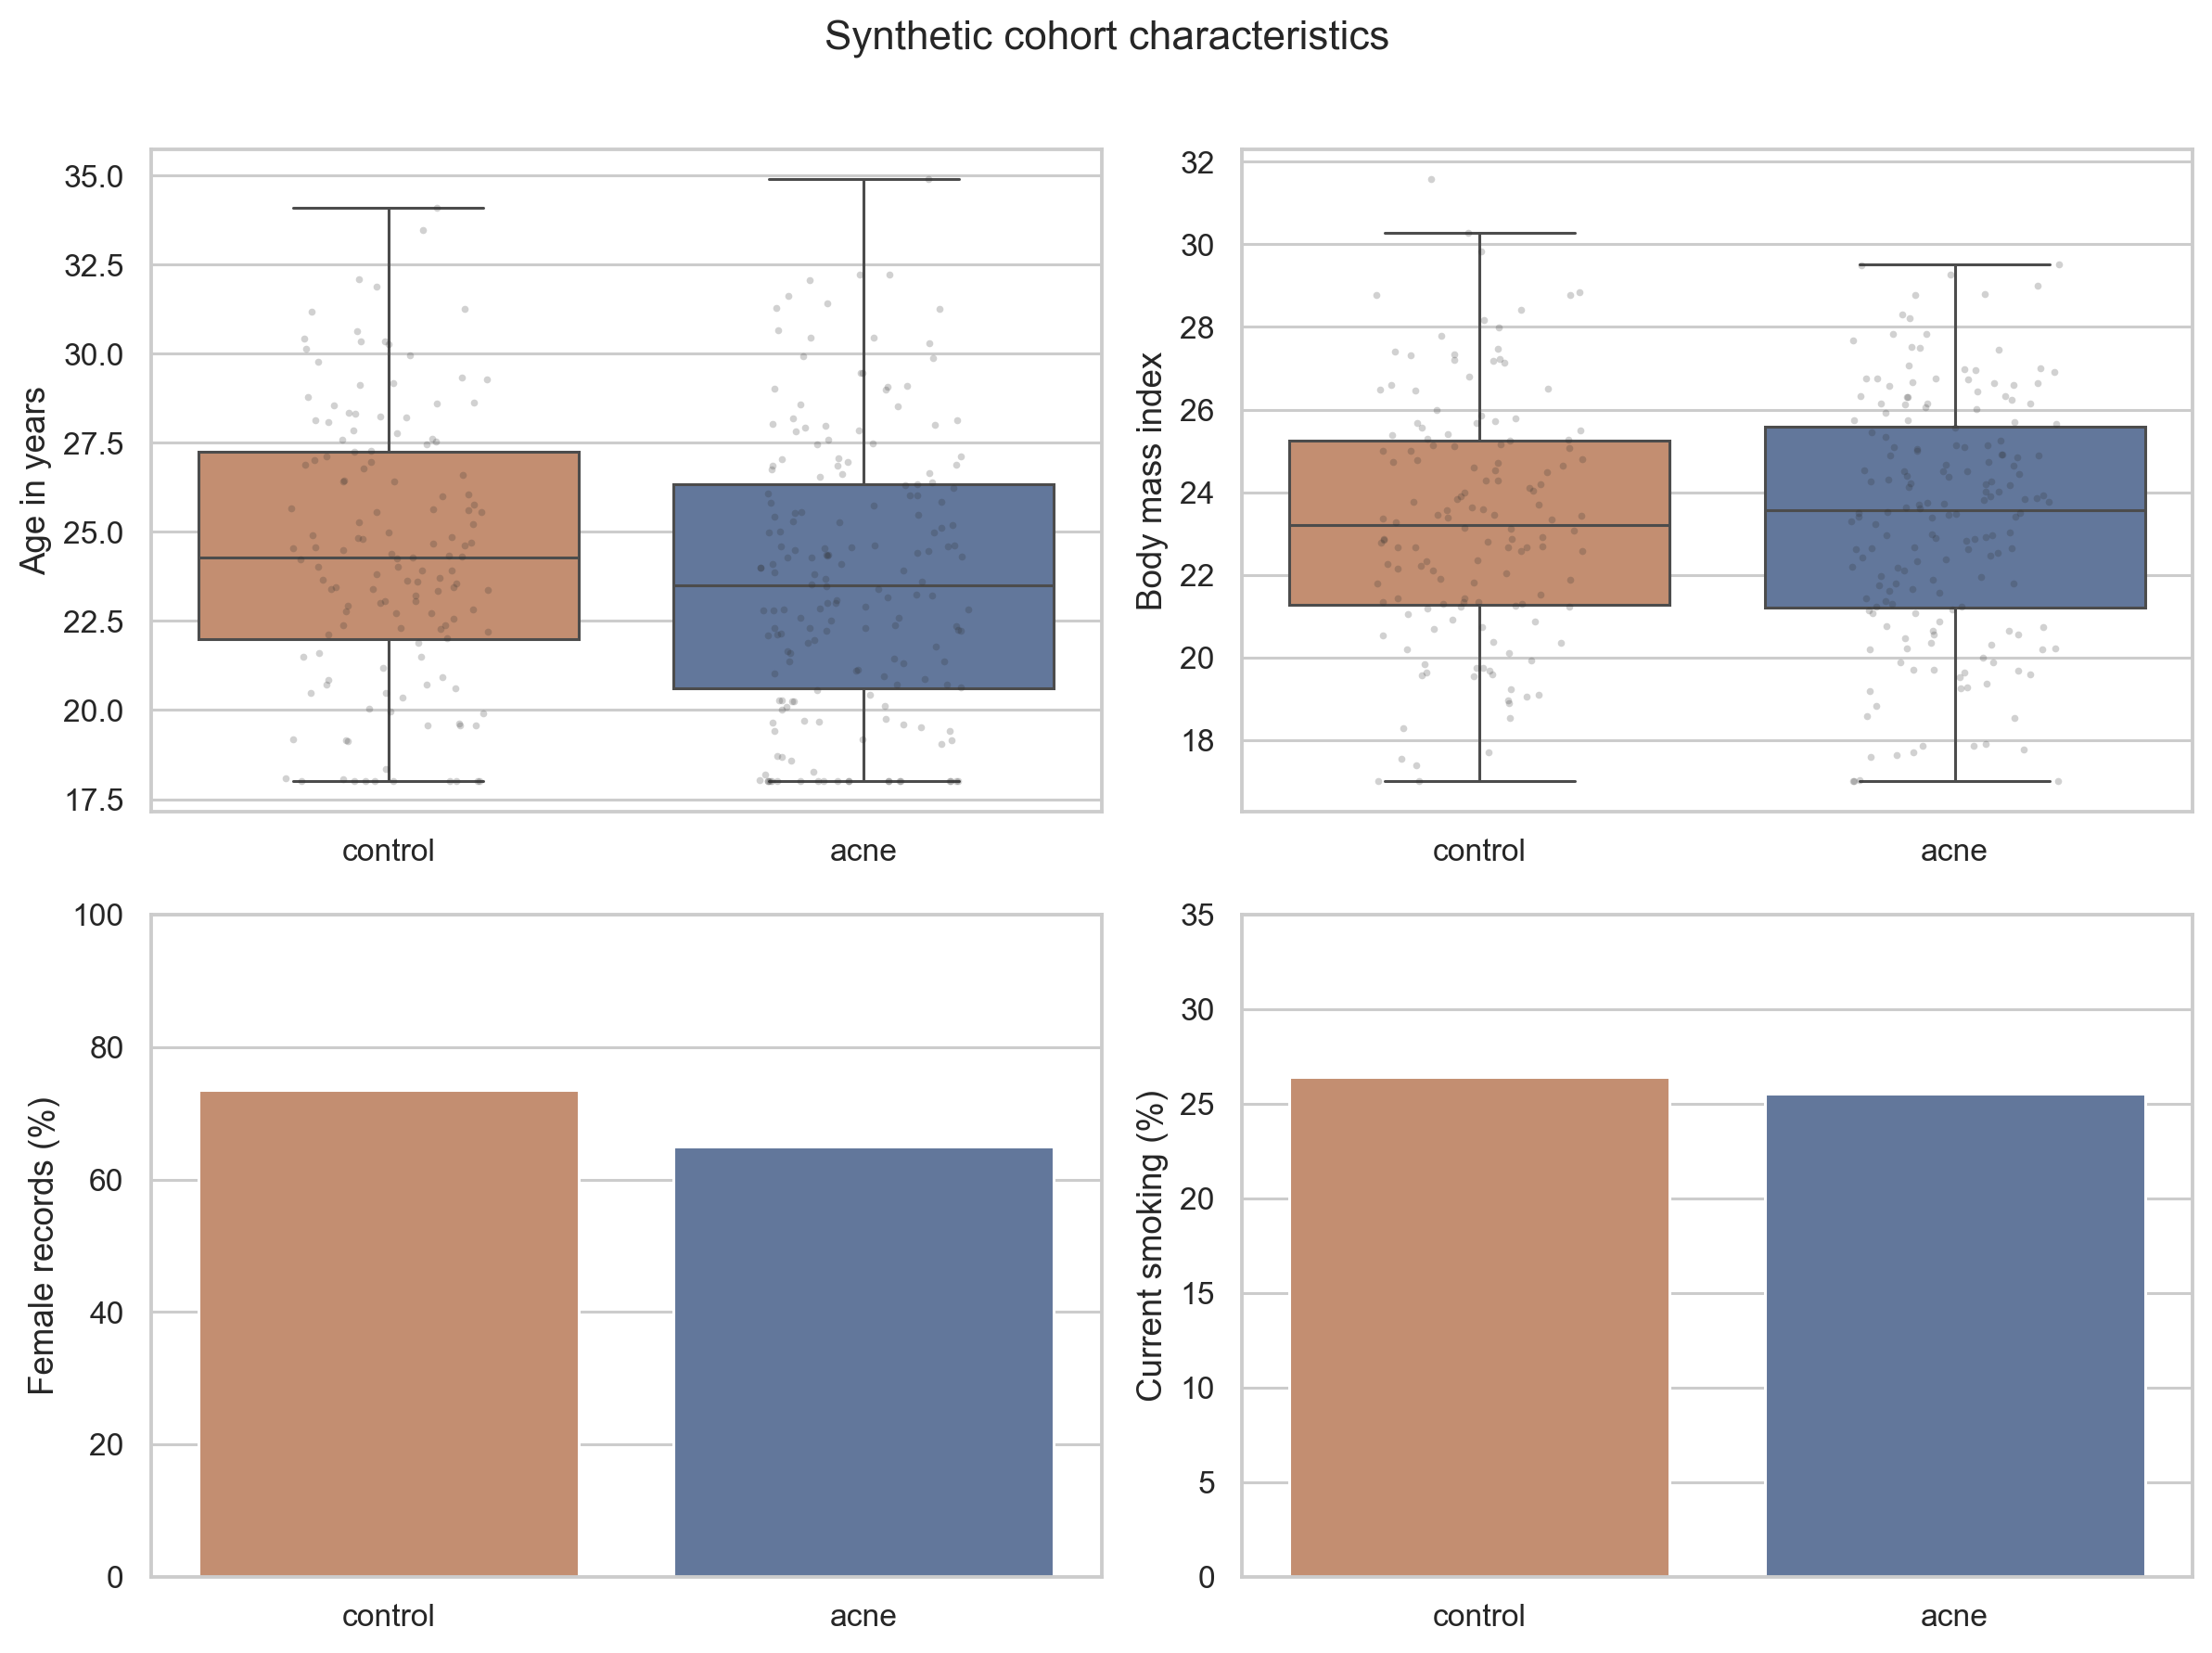

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, variable, label in [
    (axes[0, 0], "age", "Age in years"),
    (axes[0, 1], "bmi", "Body mass index"),
]:
    sns.boxplot(
        data=df,
        x="group",
        y=variable,
        order=["control", "acne"],
        hue="group",
        palette={"control": "#D08A64", "acne": "#5875A4"},
        legend=False,
        showfliers=False,
        ax=ax,
    )
    sns.stripplot(
        data=df,
        x="group",
        y=variable,
        order=["control", "acne"],
        color="#2f2f2f",
        alpha=0.22,
        jitter=0.22,
        size=2.5,
        ax=ax,
    )
    ax.set_xlabel("")
    ax.set_ylabel(label)

proportion_rows = []
for group in ["control", "acne"]:
    subset = df.loc[df["group"].eq(group)]
    proportion_rows.extend(
        [
            {"group": group, "measure": "Female", "percent": 100 * subset["sex_female"].mean()},
            {"group": group, "measure": "Current smoking", "percent": 100 * subset["smoke"].mean()},
        ]
    )
proportions = pd.DataFrame(proportion_rows)

sns.barplot(
    data=proportions.loc[proportions["measure"].eq("Female")],
    x="group", y="percent", order=["control", "acne"], hue="group",
    palette={"control": "#D08A64", "acne": "#5875A4"}, legend=False, ax=axes[1, 0]
)
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Female records (%)")
axes[1, 0].set_ylim(0, 100)

sns.barplot(
    data=proportions.loc[proportions["measure"].eq("Current smoking")],
    x="group", y="percent", order=["control", "acne"], hue="group",
    palette={"control": "#D08A64", "acne": "#5875A4"}, legend=False, ax=axes[1, 1]
)
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Current smoking (%)")
axes[1, 1].set_ylim(0, 35)

fig.suptitle("Synthetic cohort characteristics", y=1.01)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "00_synthetic_demographic_balance.png", dpi=220, bbox_inches="tight")
plt.close(fig)
display(Image(
    filename=str(FIGURE_DIR / "00_synthetic_demographic_balance.png"),
    alt="Age, body mass index, female sex, and smoking distributions in the synthetic control and acne groups.",
))

## Synthetic clinical profile

Clinical variables describe the artificial acne group only. They provide realistic data types for later subgroup and correlation examples. Their distributions are not estimates of real-world prevalence.

In [7]:
acne_df = df.loc[df["group"].eq("acne")].copy()

clinical_profile = pd.DataFrame(
    {
        "measure": [
            "GAGS score",
            "Disease duration in years",
            "Scarring",
            "Family history",
            "Trunk or back involvement",
            "Seborrhea",
        ],
        "synthetic_summary": [
            median_iqr(acne_df["gags"]),
            median_iqr(acne_df["disease_duration"]),
            f"{acne_df['scarring'].mean() * 100:.1f}%",
            f"{acne_df['family_history'].mean() * 100:.1f}%",
            f"{acne_df['trunk_back'].mean() * 100:.1f}%",
            f"{acne_df['seborrhea'].mean() * 100:.1f}%",
        ],
    }
)
clinical_profile.to_csv(TABLE_DIR / "02_clinical_profile.csv", index=False)
clinical_profile

,measure,synthetic_summary
0,GAGS score,"16.81 [11.79, 23.93]"
1,Disease duration in years,"7.20 [3.70, 10.46]"
2,Scarring,46.1%
3,Family history,26.7%
4,Trunk or back involvement,51.1%
5,Seborrhea,56.7%


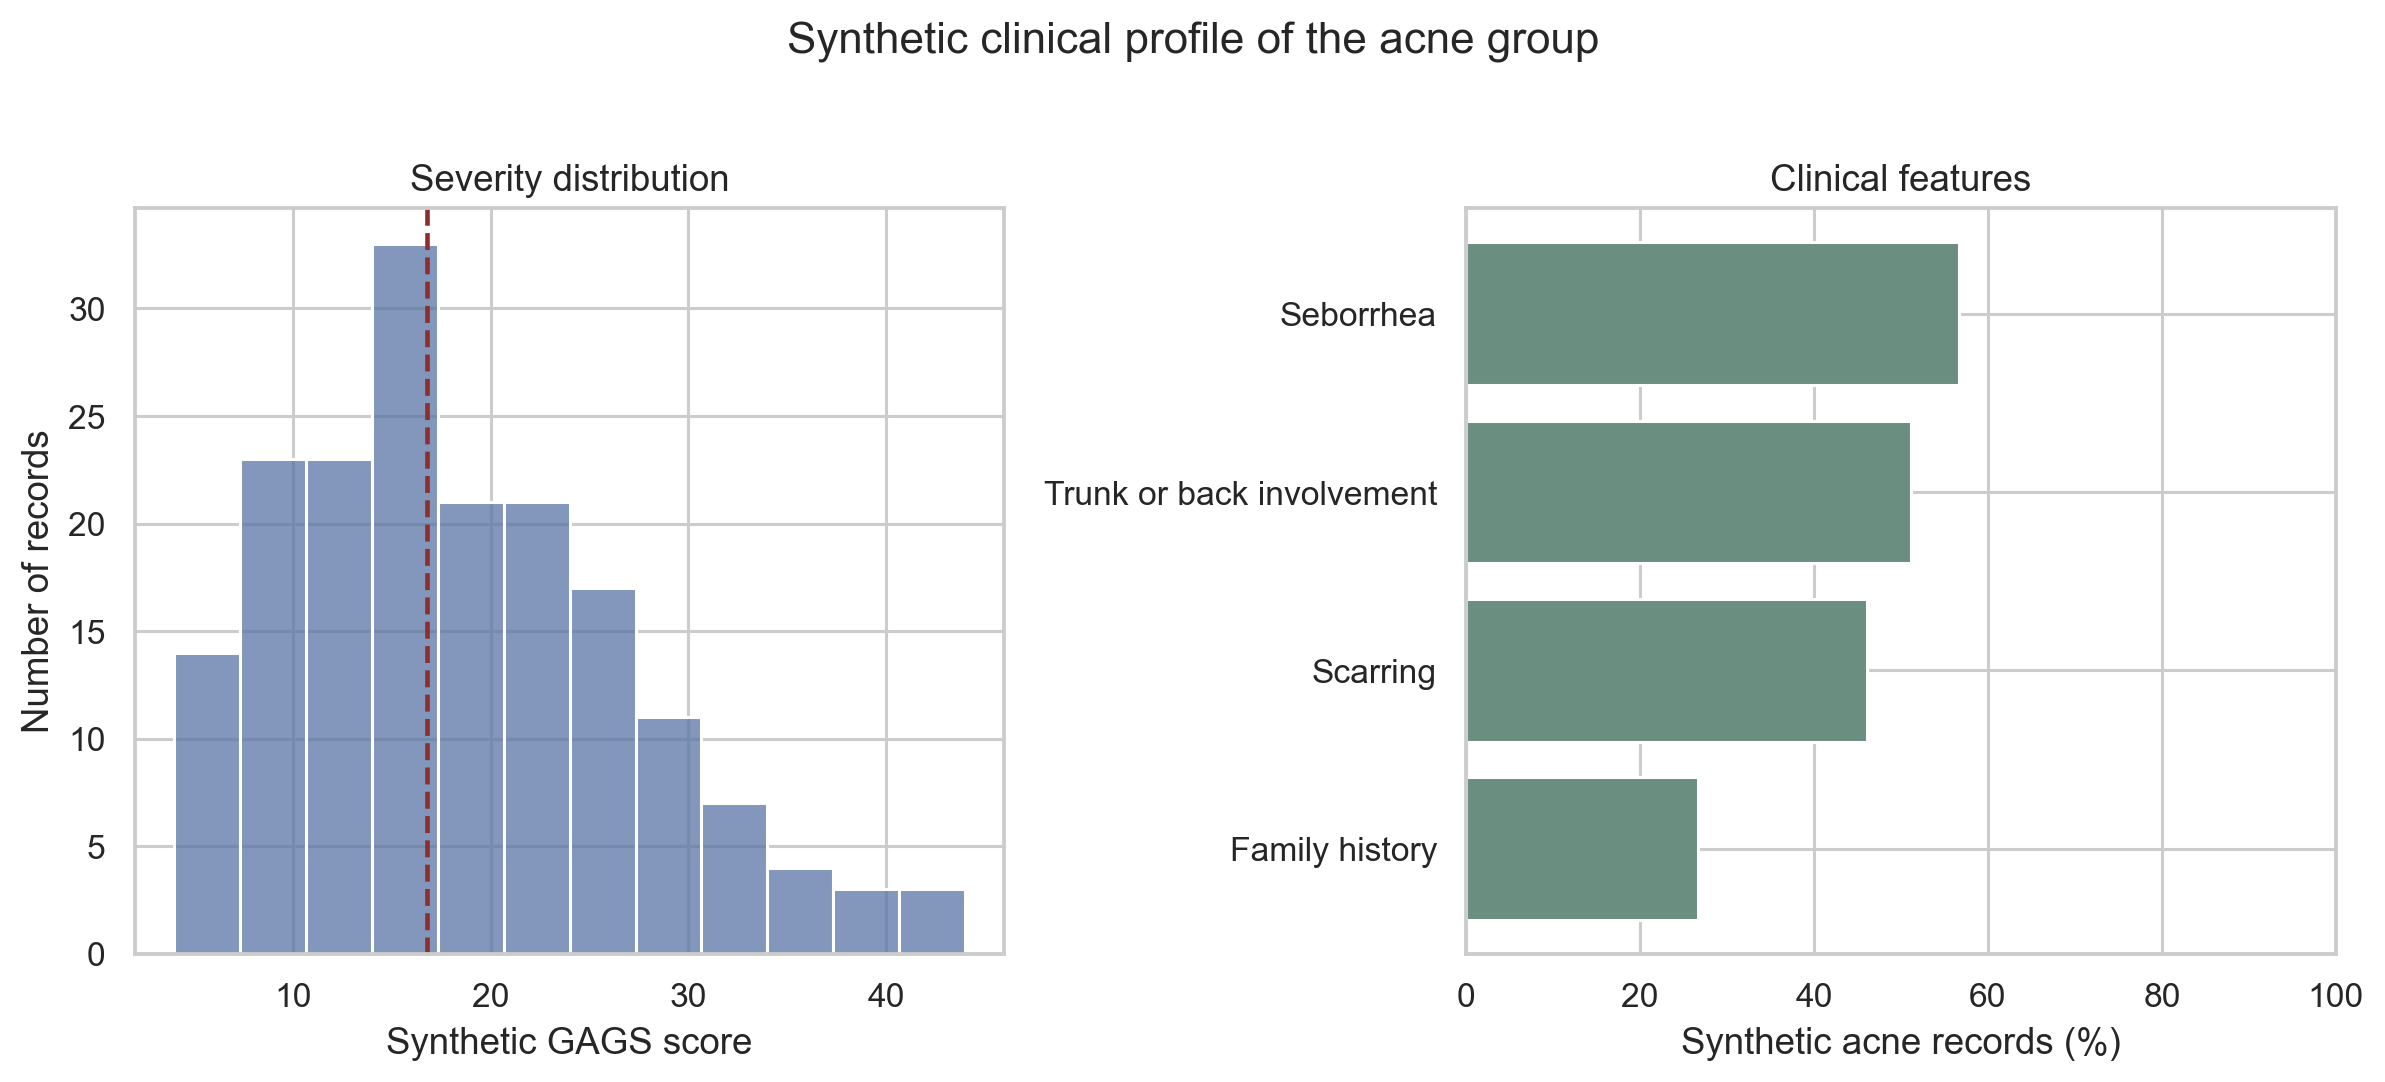

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

sns.histplot(acne_df["gags"].dropna(), bins=12, color="#5875A4", ax=axes[0])
axes[0].axvline(acne_df["gags"].median(), color="#8B2E2E", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Synthetic GAGS score")
axes[0].set_ylabel("Number of records")
axes[0].set_title("Severity distribution")

feature_labels = {
    "scarring": "Scarring",
    "family_history": "Family history",
    "trunk_back": "Trunk or back involvement",
    "seborrhea": "Seborrhea",
}
clinical_percent = pd.Series(
    {label: 100 * acne_df[variable].mean() for variable, label in feature_labels.items()}
).sort_values()
axes[1].barh(clinical_percent.index, clinical_percent.values, color="#6A8E7F")
axes[1].set_xlim(0, 100)
axes[1].set_xlabel("Synthetic acne records (%)")
axes[1].set_title("Clinical features")

fig.suptitle("Synthetic clinical profile of the acne group", y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "00b_synthetic_clinical_profile.png", dpi=220, bbox_inches="tight")
plt.close(fig)
display(Image(
    filename=str(FIGURE_DIR / "00b_synthetic_clinical_profile.png"),
    alt="Distribution of synthetic GAGS scores and prevalence of four synthetic clinical features in the acne group.",
))

## Check the reference measurement

ΔCq assumes that the reference is suitable for normalization. A group difference in the reference can create, erase, or reverse an apparent target difference.

The main synthetic reference is expected to be stable. The deliberately unstable reference should fail this check.

In [9]:
reference_checks = []
for variable, label in [
    ("cq_reference", "Main synthetic reference"),
    ("cq_reference_unstable", "Deliberately unstable reference"),
]:
    result = compare_groups(df, variable)
    reference_checks.append(
        {
            "reference": label,
            "acne": result["acne"],
            "control": result["control"],
            "rank_biserial_r": result["rank_biserial_r"],
            "p_value": result["p_value"],
        }
    )

reference_checks = pd.DataFrame(reference_checks)
reference_checks.to_csv(TABLE_DIR / "03_reference_checks.csv", index=False)
reference_checks

,reference,acne,control,rank_biserial_r,p_value
0,Main synthetic reference,"26.53 [26.10, 26.97]","26.50 [25.95, 26.83]",0.071,0.279
1,Deliberately unstable reference,"28.11 [27.62, 28.49]","26.45 [25.99, 26.92]",0.906,0.000


## Primary ΔCq comparison

The definition used here is `ΔCq = Cq(target) - Cq(reference)`.

A higher ΔCq means lower relative expression. This direction is stated before looking at results so that the biological interpretation cannot be reversed later.

In [10]:
primary = pd.DataFrame(
    [compare_groups(df, "dcq_25"), compare_groups(df, "dcq_143")]
)
primary["q_value"] = multipletests(primary["p_value"], method="fdr_bh")[1]
primary["relative_expression_ratio"] = [
    2 ** -(
        df.loc[df.group.eq("acne"), variable].mean()
        - df.loc[df.group.eq("control"), variable].mean()
    )
    for variable in primary["variable"]
]
primary["interpretation"] = np.where(
    primary["median_difference"] > 0,
    "Lower relative expression in synthetic acne records",
    "Higher relative expression in synthetic acne records",
)
primary.to_csv(TABLE_DIR / "04_primary_results.csv", index=False)
primary

,variable,acne,control,median_difference,difference_ci_low,difference_ci_high,rank_biserial_r,p_value,n_acne,n_control,q_value,relative_expression_ratio,interpretation
0,dcq_25,"-0.67 [-1.44, 0.18]","-1.69 [-2.37, -0.72]",1.012,0.691,1.295,0.435,0.000,180,140,0.000,0.545,Lower relative expression in synthetic acne re...
1,dcq_143,"-1.04 [-1.80, -0.29]","-2.25 [-2.88, -1.54]",1.214,0.878,1.494,0.547,0.000,180,140,0.000,0.378,Lower relative expression in synthetic acne re...


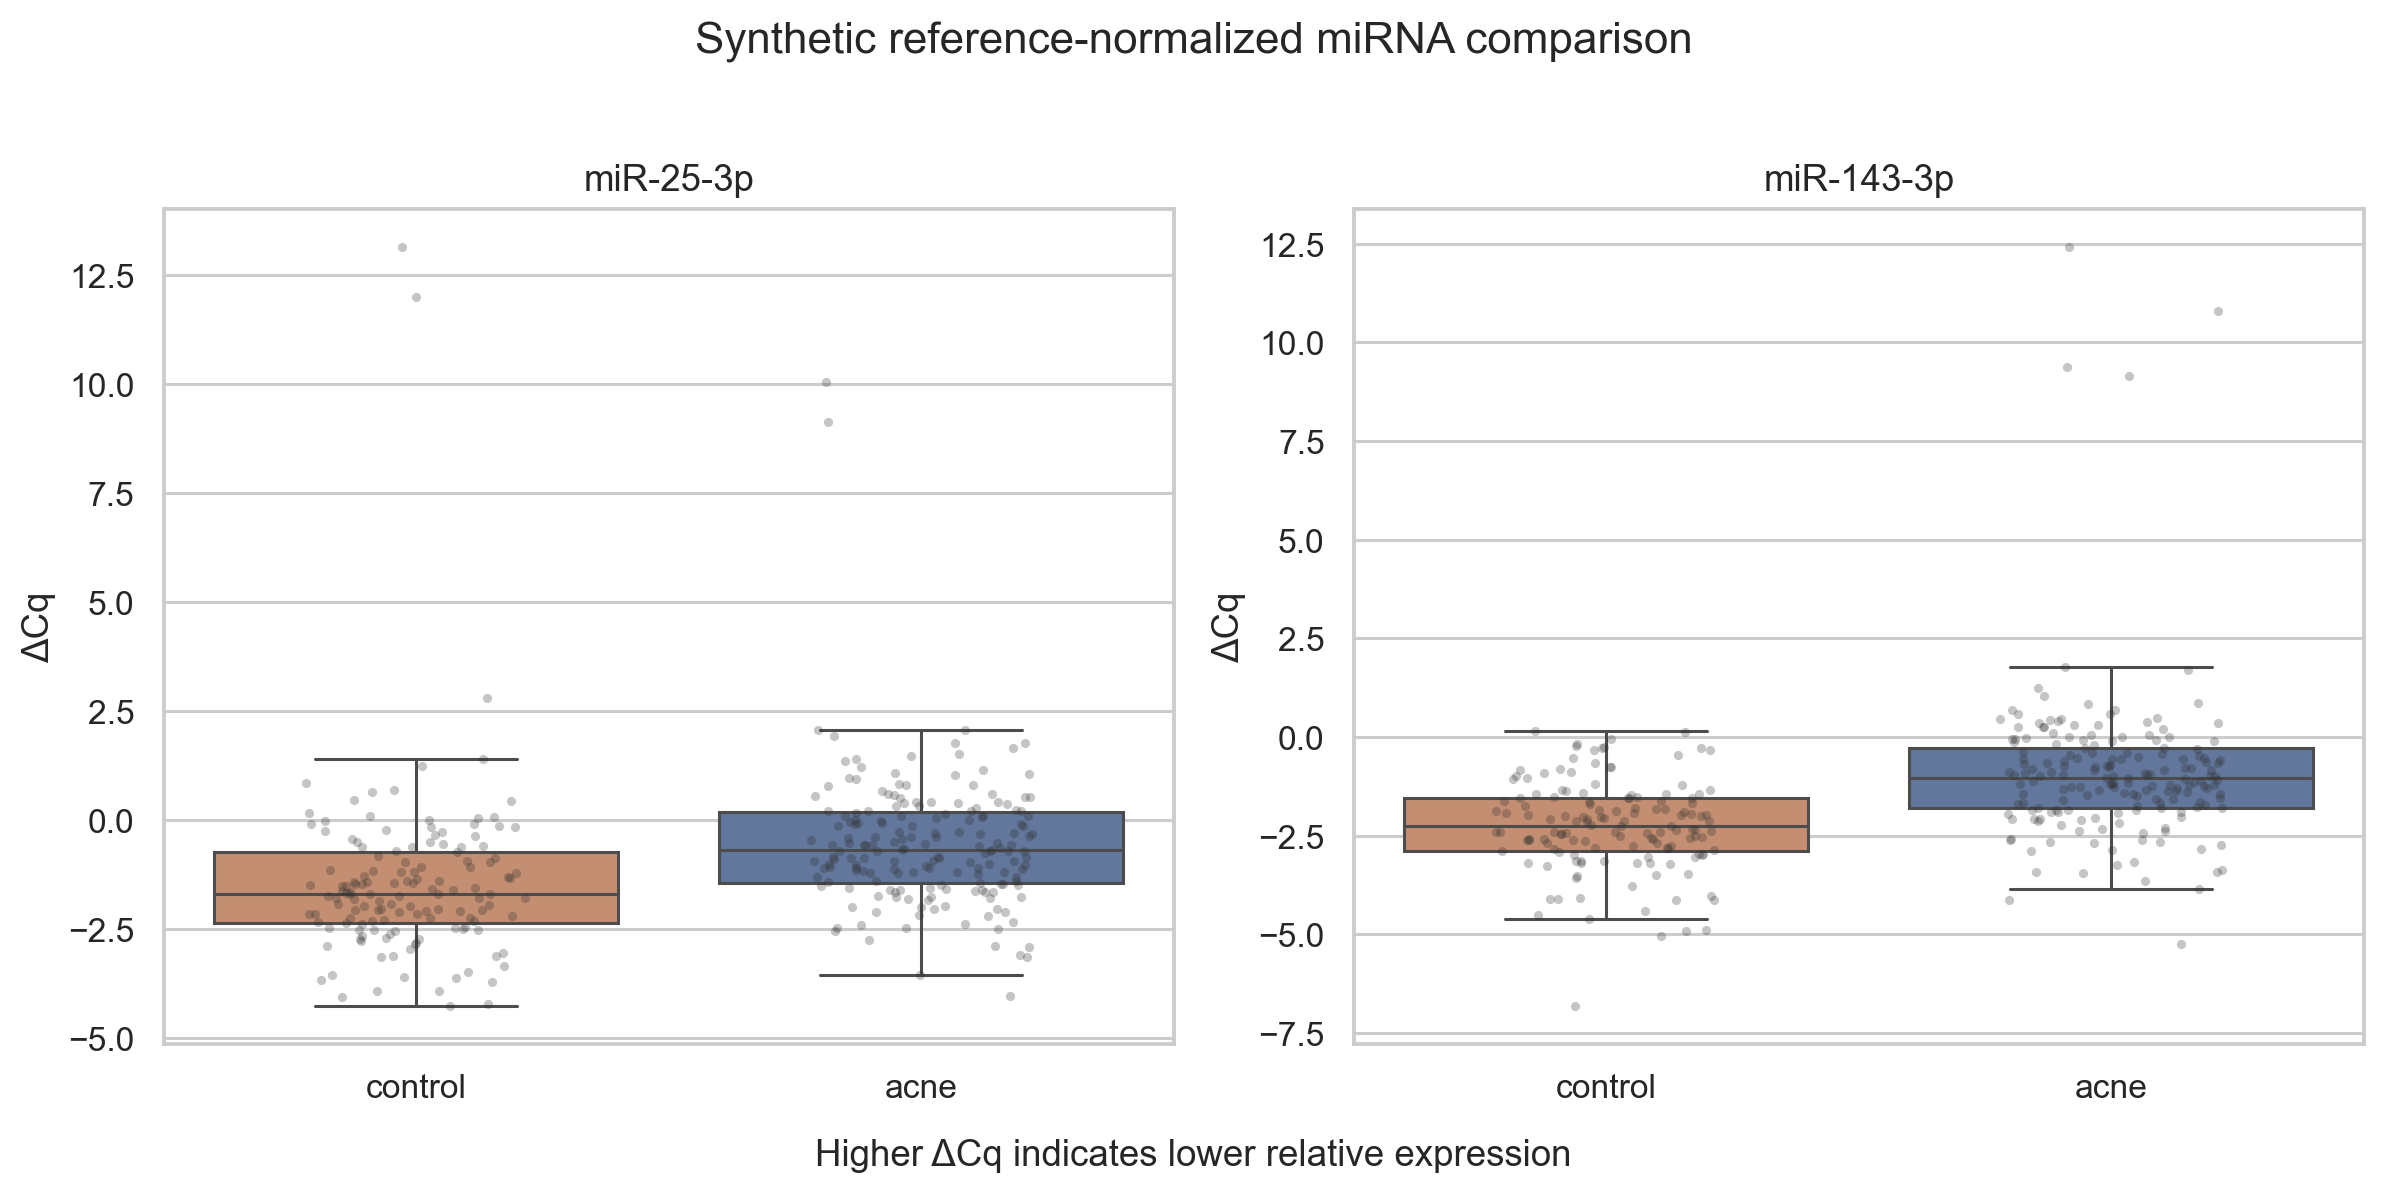

In [11]:
plot_df = df.melt(
    id_vars=["group", "qc_pass"],
    value_vars=["dcq_25", "dcq_143"],
    var_name="marker",
    value_name="delta_cq",
)
plot_df["marker"] = plot_df["marker"].map(
    {"dcq_25": "miR-25-3p", "dcq_143": "miR-143-3p"}
)

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=False)
for ax, marker in zip(axes, ["miR-25-3p", "miR-143-3p"]):
    subset = plot_df.loc[plot_df["marker"].eq(marker)]
    sns.boxplot(
        data=subset,
        x="group",
        y="delta_cq",
        order=["control", "acne"],
        hue="group",
        palette={"control": "#D08A64", "acne": "#5875A4"},
        legend=False,
        showfliers=False,
        ax=ax,
    )
    sns.stripplot(
        data=subset,
        x="group",
        y="delta_cq",
        order=["control", "acne"],
        color="#2f2f2f",
        alpha=0.28,
        jitter=0.22,
        size=3,
        ax=ax,
    )
    ax.set_title(marker)
    ax.set_xlabel("")
    ax.set_ylabel("ΔCq")

fig.suptitle("Synthetic reference-normalized miRNA comparison", y=1.02)
fig.text(0.5, -0.02, "Higher ΔCq indicates lower relative expression", ha="center")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_synthetic_primary_expression.png", dpi=220, bbox_inches="tight")
plt.close(fig)
display(Image(
    filename=str(FIGURE_DIR / "01_synthetic_primary_expression.png"),
    alt="Synthetic box plots comparing reference-normalized miR-25-3p and miR-143-3p ΔCq values in control and acne groups.",
))

## Normalization sensitivity

The same targets are viewed three ways. The main ΔCq uses a stable synthetic reference. The second ΔCq uses a reference that was intentionally made unstable. The final view uses raw target Cq.

The unstable-reference result is a warning example. It is not a competing analysis strategy.

In [12]:
normalization_specs = [
    ("Stable reference ΔCq", "miR-25-3p", "dcq_25"),
    ("Stable reference ΔCq", "miR-143-3p", "dcq_143"),
    ("Unstable reference ΔCq", "miR-25-3p", "dcq_badref_25"),
    ("Unstable reference ΔCq", "miR-143-3p", "dcq_badref_143"),
    ("Raw target Cq", "miR-25-3p", "cq_25"),
    ("Raw target Cq", "miR-143-3p", "cq_143"),
]

normalization_rows = []
for approach, marker, variable in normalization_specs:
    result = compare_groups(df, variable)
    normalization_rows.append(
        {
            "approach": approach,
            "marker": marker,
            "acne": result["acne"],
            "control": result["control"],
            "rank_biserial_r": result["rank_biserial_r"],
            "p_value": result["p_value"],
        }
    )

normalization = pd.DataFrame(normalization_rows)
normalization["q_within_approach"] = normalization.groupby("approach")["p_value"].transform(
    lambda values: multipletests(values, method="fdr_bh")[1]
)
normalization.to_csv(TABLE_DIR / "05_normalization_sensitivity.csv", index=False)
normalization

,approach,marker,acne,control,rank_biserial_r,p_value,q_within_approach
0,Stable reference ΔCq,miR-25-3p,"-0.67 [-1.44, 0.18]","-1.69 [-2.37, -0.72]",0.435,0.000,0.000
1,Stable reference ΔCq,miR-143-3p,"-1.04 [-1.80, -0.29]","-2.25 [-2.88, -1.54]",0.547,0.000,0.000
2,Unstable reference ΔCq,miR-25-3p,"-2.16 [-3.00, -1.48]","-1.70 [-2.33, -0.75]",-0.249,0.000,0.000
3,Unstable reference ΔCq,miR-143-3p,"-2.56 [-3.32, -1.83]","-2.28 [-2.91, -1.59]",-0.173,0.008,0.008
4,Raw target Cq,miR-25-3p,"25.87 [25.39, 26.55]","24.83 [24.18, 25.57]",0.573,0.000,0.000
5,Raw target Cq,miR-143-3p,"25.45 [24.76, 26.11]","24.26 [23.62, 24.64]",0.677,0.000,0.000


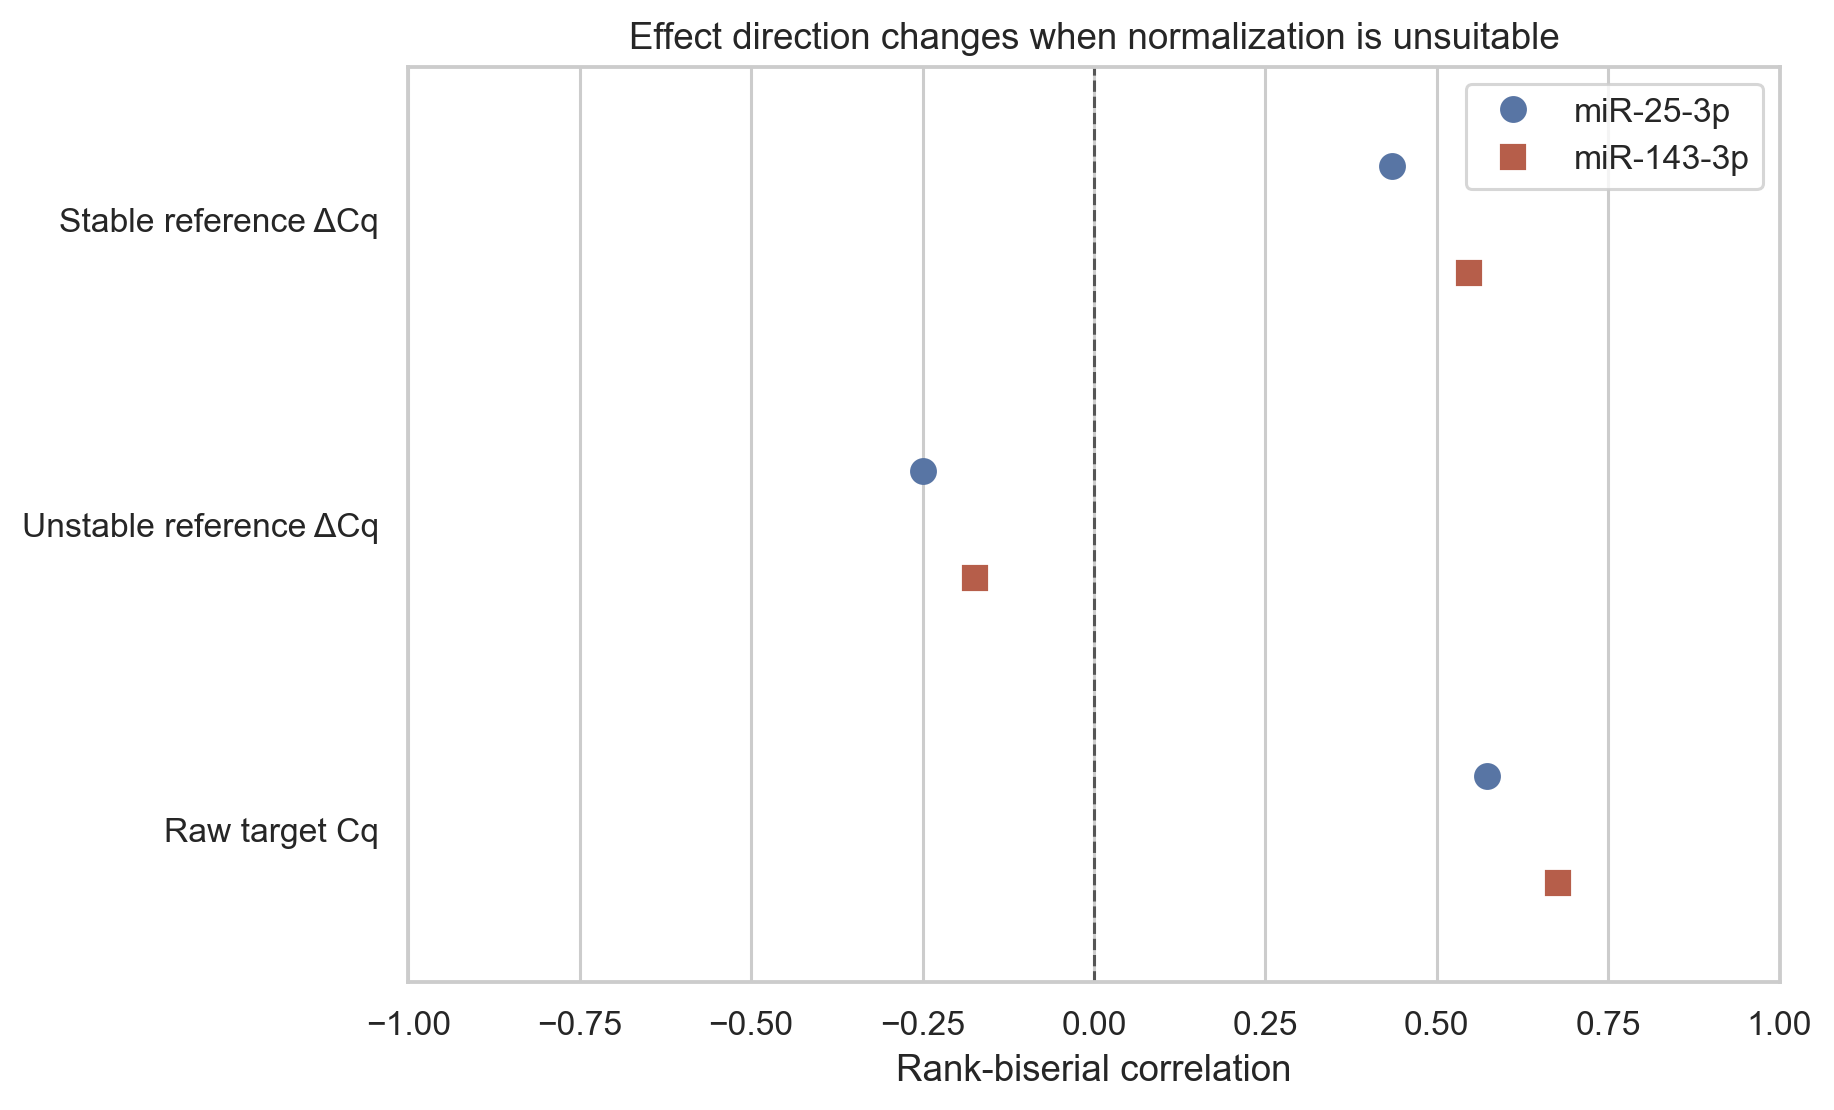

In [13]:
normalization_plot = normalization.copy()
normalization_plot["marker"] = pd.Categorical(
    normalization_plot["marker"], categories=["miR-25-3p", "miR-143-3p"], ordered=True
)

fig, ax = plt.subplots(figsize=(8.5, 5.2))
sns.pointplot(
    data=normalization_plot,
    x="rank_biserial_r",
    y="approach",
    hue="marker",
    dodge=0.35,
    linestyles="none",
    markers=["o", "s"],
    palette={"miR-25-3p": "#5875A4", "miR-143-3p": "#B65E4A"},
    errorbar=None,
    ax=ax,
)
ax.axvline(0, color="#555555", linestyle="--", linewidth=1)
ax.set_xlim(-1, 1)
ax.set_xlabel("Rank-biserial correlation")
ax.set_ylabel("")
ax.set_title("Effect direction changes when normalization is unsuitable")
ax.legend(title="")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "01b_synthetic_normalization_sensitivity.png", dpi=220, bbox_inches="tight")
plt.close(fig)
display(Image(
    filename=str(FIGURE_DIR / "01b_synthetic_normalization_sensitivity.png"),
    alt="Rank-biserial effect estimates for two synthetic miRNAs under stable-reference, unstable-reference, and raw Cq analyses.",
))

## Clinical correlations

These analyses use synthetic acne records only. They test associations with severity, disease duration, and age at onset. They are kept in a separate exploratory family.

In [14]:
correlation_rows = []
for marker in ["dcq_25", "dcq_143"]:
    for clinical in ["gags", "disease_duration", "age_onset", "age", "bmi"]:
        subset = acne_df[[marker, clinical]].dropna()
        rho, p_value = stats.spearmanr(subset[marker], subset[clinical])
        correlation_rows.append(
            {
                "marker": marker,
                "clinical_variable": clinical,
                "spearman_rho": rho,
                "p_value": p_value,
                "n": len(subset),
            }
        )

clinical_correlations = pd.DataFrame(correlation_rows)
clinical_correlations["q_value"] = multipletests(
    clinical_correlations["p_value"], method="fdr_bh"
)[1]
clinical_correlations.to_csv(TABLE_DIR / "06_clinical_correlations.csv", index=False)
clinical_correlations

,marker,clinical_variable,spearman_rho,p_value,n,q_value
0,dcq_25,gags,0.011,0.887,180,0.887
1,dcq_25,disease_duration,-0.102,0.172,180,0.431
2,dcq_25,age_onset,0.022,0.767,180,0.884
3,dcq_25,age,-0.083,0.269,180,0.538
4,dcq_25,bmi,-0.033,0.661,180,0.884
5,dcq_143,gags,-0.113,0.130,180,0.431
6,dcq_143,disease_duration,-0.158,0.034,180,0.343
7,dcq_143,age_onset,0.064,0.396,180,0.660
8,dcq_143,age,-0.132,0.077,180,0.384
9,dcq_143,bmi,0.019,0.795,180,0.884


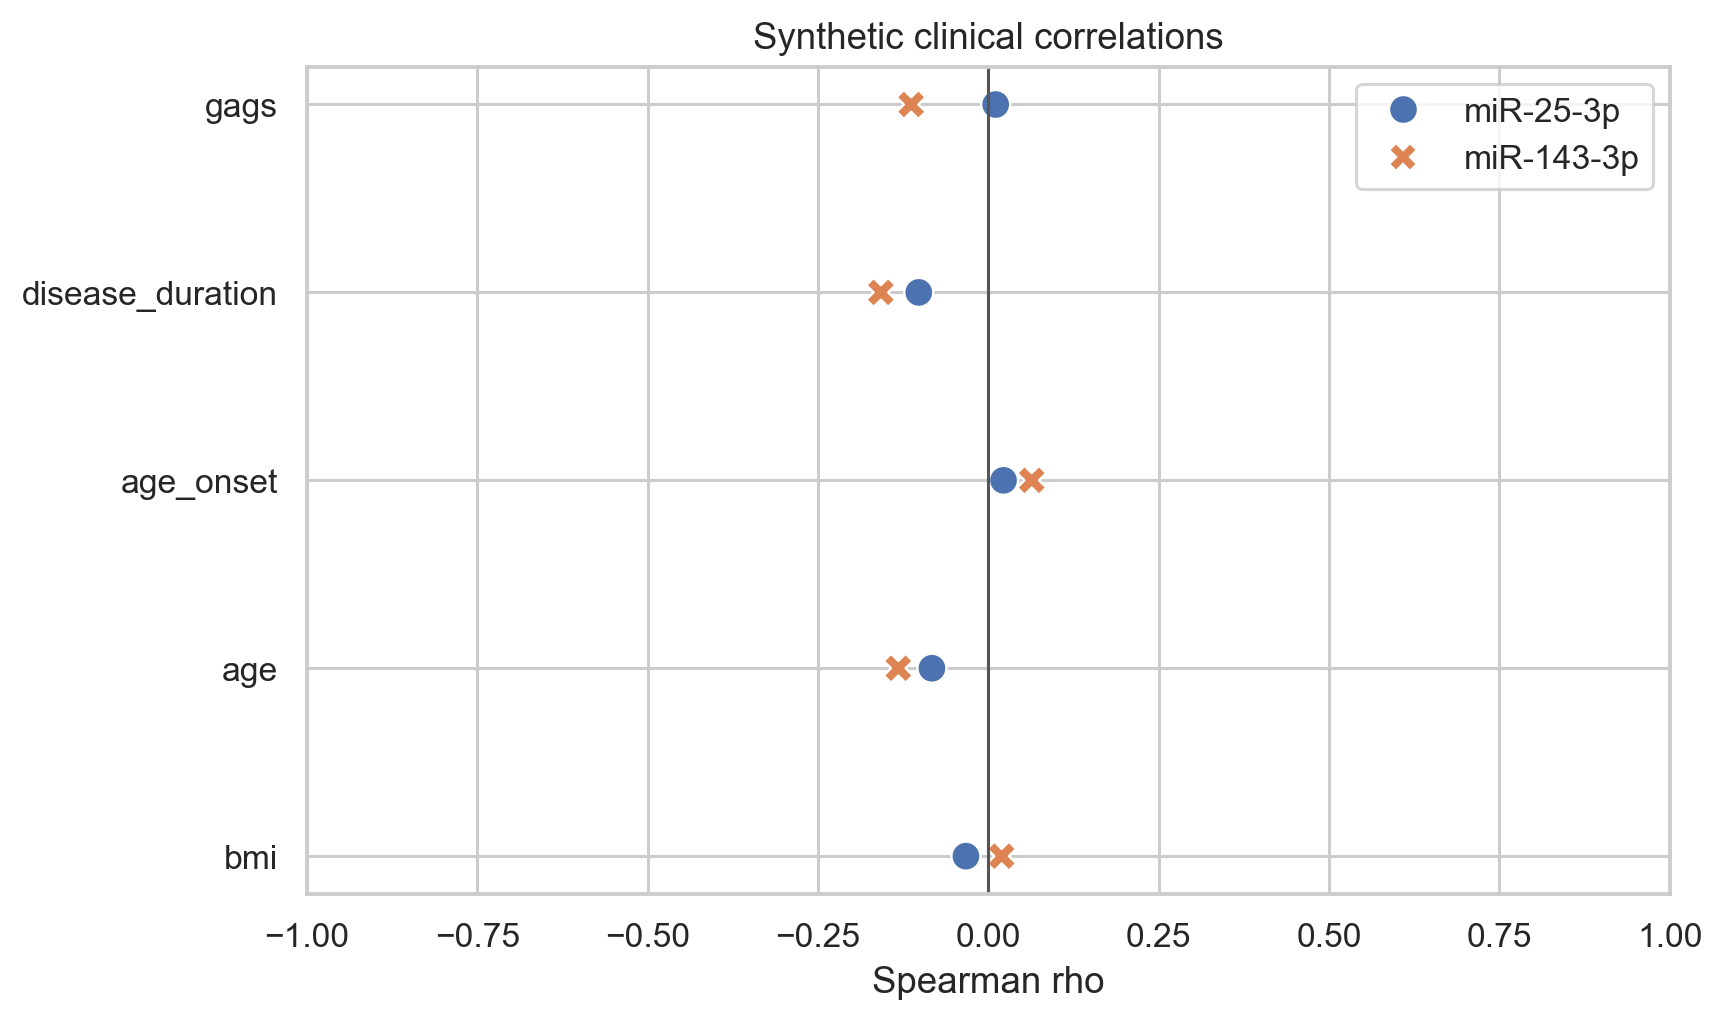

In [15]:
corr_plot = clinical_correlations.copy()
corr_plot["label"] = corr_plot["marker"].map(
    {"dcq_25": "miR-25-3p", "dcq_143": "miR-143-3p"}
)

fig, ax = plt.subplots(figsize=(8, 4.8))
sns.scatterplot(
    data=corr_plot,
    x="spearman_rho",
    y="clinical_variable",
    hue="label",
    style="label",
    s=90,
    ax=ax,
)
ax.axvline(0, color="#555555", linewidth=1)
ax.set_xlim(-1, 1)
ax.set_xlabel("Spearman rho")
ax.set_ylabel("")
ax.set_title("Synthetic clinical correlations")
ax.legend(title="")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_synthetic_clinical_correlations.png", dpi=220, bbox_inches="tight")
plt.close(fig)
display(Image(
    filename=str(FIGURE_DIR / "02_synthetic_clinical_correlations.png"),
    alt="Synthetic Spearman correlations between two miRNA ΔCq measures and five clinical variables.",
))

## Subgroup analysis

Subgroup comparisons can multiply quickly. Each result is labelled exploratory and corrected within one subgroup family. Small groups are not promoted as discoveries.

In [16]:
subgroup_variables = [
    "scarring",
    "family_history",
    "trunk_back",
    "seborrhea",
    "smoke",
]

subgroup_rows = []
for subgroup in subgroup_variables:
    for marker in ["dcq_25", "dcq_143"]:
        subset = acne_df[[subgroup, marker]].dropna()
        x = subset.loc[subset[subgroup].eq(1), marker]
        y = subset.loc[subset[subgroup].eq(0), marker]
        if min(len(x), len(y)) < 10:
            continue
        test = stats.mannwhitneyu(x, y, alternative="two-sided")
        effect = rank_biserial(x, y)
        ci_low, ci_high = bootstrap_statistic(
            x, y, rank_biserial, n_boot=1000, seed=SEED + len(subgroup_rows)
        )
        subgroup_rows.append(
            {
                "subgroup": subgroup,
                "marker": marker,
                "n_present": len(x),
                "n_absent": len(y),
                "rank_biserial_r": effect,
                "ci_low": ci_low,
                "ci_high": ci_high,
                "p_value": test.pvalue,
            }
        )

subgroups = pd.DataFrame(subgroup_rows)
subgroups["q_value"] = multipletests(subgroups["p_value"], method="fdr_bh")[1]
subgroups.to_csv(TABLE_DIR / "07_subgroups.csv", index=False)
subgroups

,subgroup,marker,n_present,n_absent,rank_biserial_r,ci_low,ci_high,p_value,q_value
0,scarring,dcq_25,83,97,-0.073,-0.241,0.096,0.402,0.860
1,scarring,dcq_143,83,97,-0.050,-0.215,0.119,0.562,0.860
2,family_history,dcq_25,48,132,-0.196,-0.383,-0.006,0.045,0.451
3,family_history,dcq_143,48,132,-0.050,-0.231,0.129,0.610,0.860
4,trunk_back,dcq_25,92,88,-0.076,-0.238,0.079,0.377,0.860
5,trunk_back,dcq_143,92,88,-0.025,-0.196,0.142,0.774,0.860
6,seborrhea,dcq_25,102,78,0.033,-0.146,0.212,0.704,0.860
7,seborrhea,dcq_143,102,78,0.044,-0.137,0.210,0.612,0.860
8,smoke,dcq_25,46,134,-0.054,-0.251,0.145,0.590,0.860
9,smoke,dcq_143,46,134,-0.003,-0.200,0.197,0.978,0.978


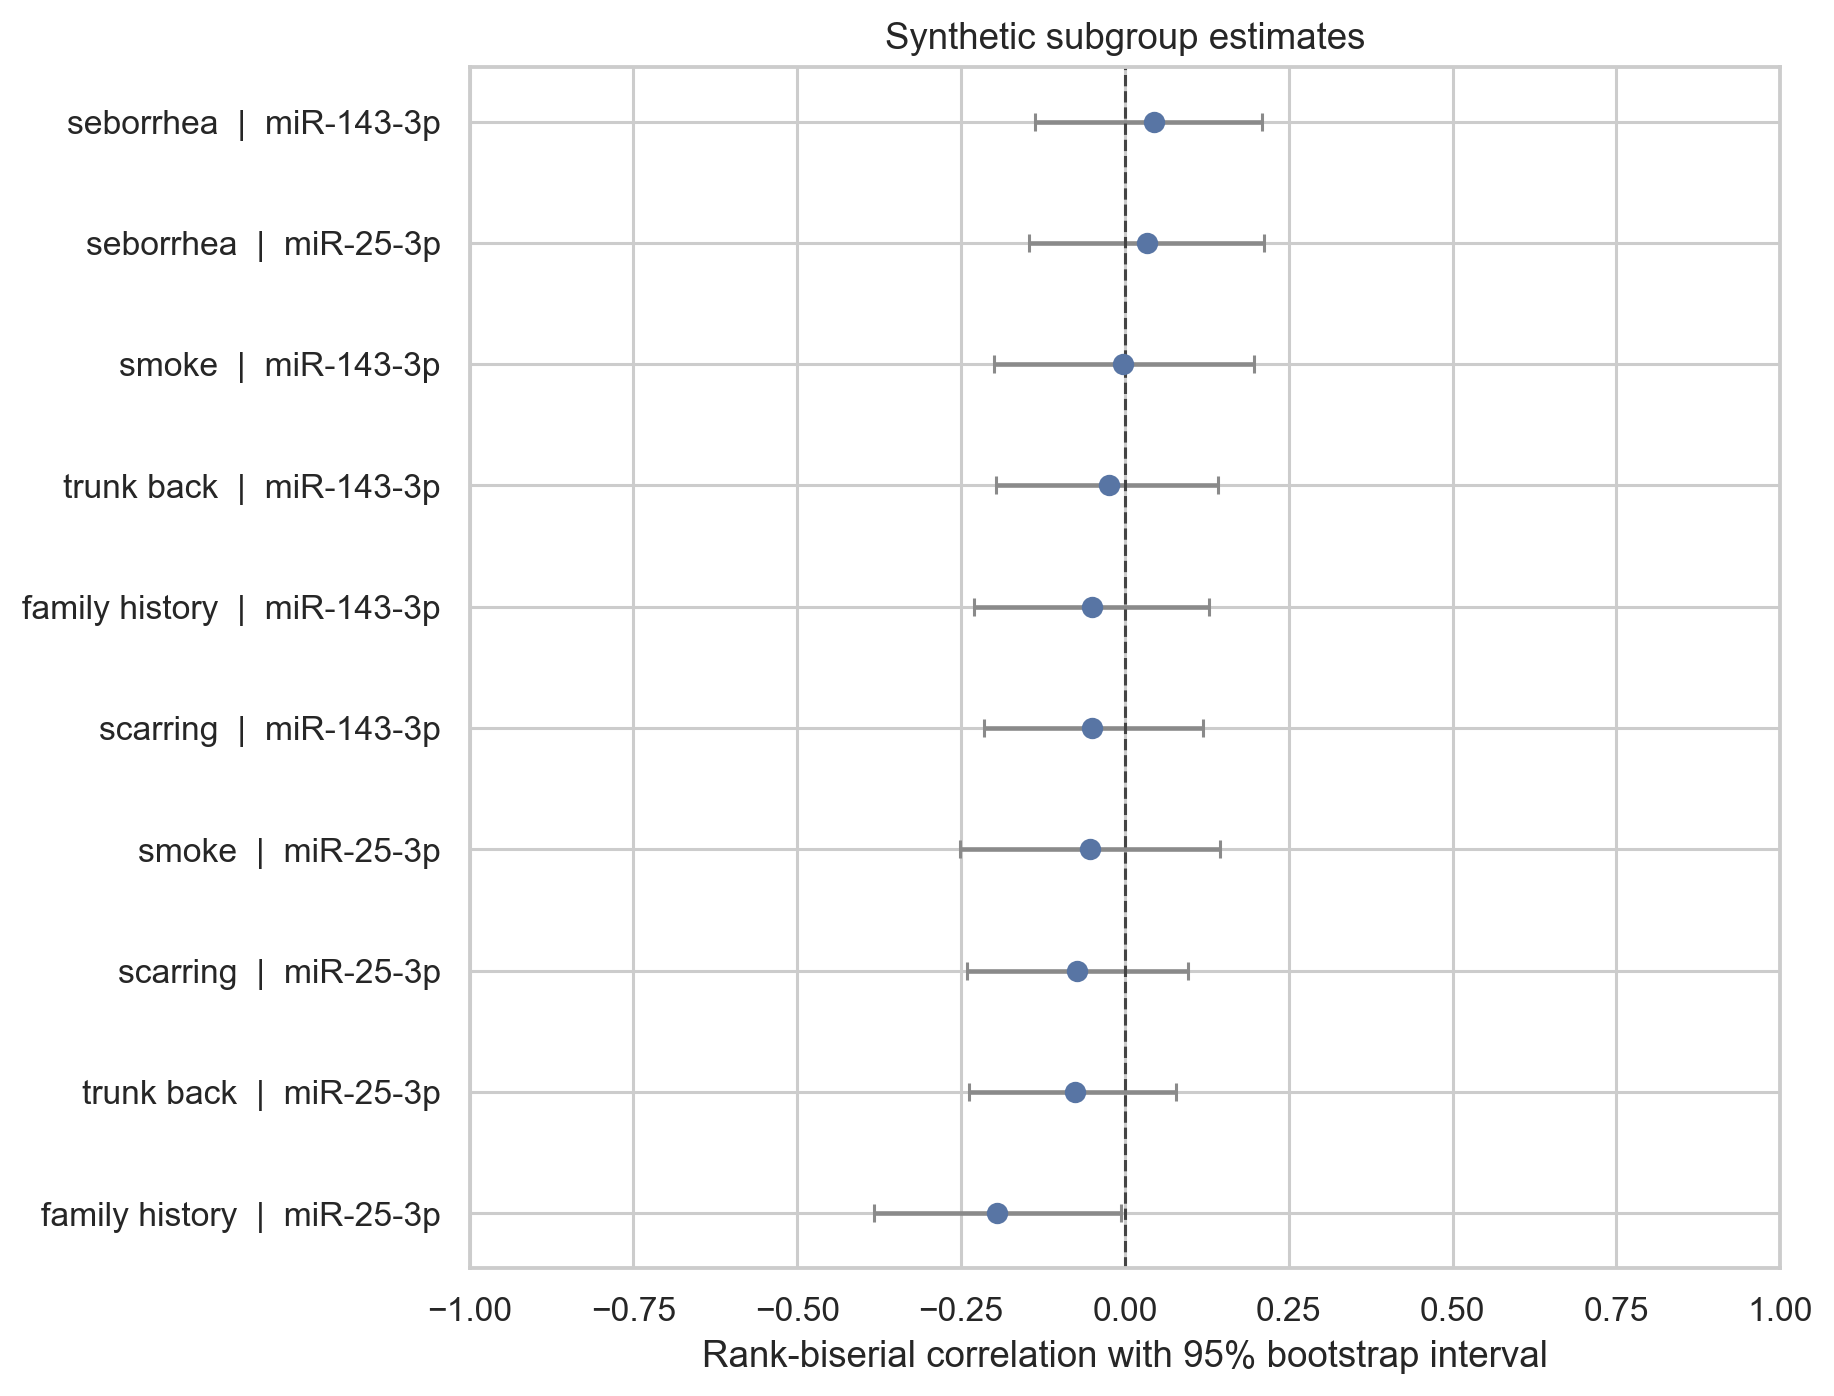

In [17]:
forest = subgroups.sort_values("rank_biserial_r").copy()
forest["label"] = (
    forest["subgroup"].str.replace("_", " ")
    + "  |  "
    + forest["marker"].map({"dcq_25": "miR-25-3p", "dcq_143": "miR-143-3p"})
)

fig, ax = plt.subplots(figsize=(8.5, 6.5))
y = np.arange(len(forest))
ax.errorbar(
    forest["rank_biserial_r"],
    y,
    xerr=[
        forest["rank_biserial_r"] - forest["ci_low"],
        forest["ci_high"] - forest["rank_biserial_r"],
    ],
    fmt="o",
    color="#5875A4",
    ecolor="#8a8a8a",
    capsize=3,
)
ax.axvline(0, color="#444444", linestyle="--", linewidth=1)
ax.set_yticks(y, forest["label"])
ax.set_xlim(-1, 1)
ax.set_xlabel("Rank-biserial correlation with 95% bootstrap interval")
ax.set_title("Synthetic subgroup estimates")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_synthetic_subgroup_forest.png", dpi=220, bbox_inches="tight")
plt.close(fig)
display(Image(
    filename=str(FIGURE_DIR / "03_synthetic_subgroup_forest.png"),
    alt="Forest plot of synthetic subgroup effect estimates with bootstrap confidence intervals.",
))

## Adjusted association models

The outcome is synthetic case status. The models estimate adjusted associations, not causal risk. Each miRNA measure is standardized so the odds ratio corresponds to a one standard deviation increase in ΔCq.

In [18]:
model_df = df.copy()
for variable in ["dcq_25", "dcq_143"]:
    model_df[f"z_{variable}"] = (
        model_df[variable] - model_df[variable].mean()
    ) / model_df[variable].std(ddof=0)
model_df["combined_score"] = model_df[["z_dcq_25", "z_dcq_143"]].mean(axis=1)

formulas = {
    "miR-25-3p": "acne ~ z_dcq_25 + age + sex_female + bmi + smoke",
    "miR-143-3p": "acne ~ z_dcq_143 + age + sex_female + bmi + smoke",
    "Combined": "acne ~ combined_score + age + sex_female + bmi + smoke",
}

key_terms = {
    "miR-25-3p": "z_dcq_25",
    "miR-143-3p": "z_dcq_143",
    "Combined": "combined_score",
}

model_rows = []
fitted_models = {}
for name, formula in formulas.items():
    fitted = smf.glm(formula, data=model_df, family=sm.families.Binomial()).fit()
    fitted_models[name] = fitted
    term = key_terms[name]
    ci = fitted.conf_int().loc[term]
    model_rows.append(
        {
            "model": name,
            "term": term,
            "adjusted_odds_ratio": np.exp(fitted.params[term]),
            "ci_low": np.exp(ci.iloc[0]),
            "ci_high": np.exp(ci.iloc[1]),
            "p_value": fitted.pvalues[term],
            "AIC": fitted.aic,
        }
    )

adjusted_models = pd.DataFrame(model_rows)
adjusted_models.to_csv(TABLE_DIR / "08_adjusted_models.csv", index=False)
adjusted_models

,model,term,adjusted_odds_ratio,ci_low,ci_high,p_value,AIC
0,miR-25-3p,z_dcq_25,2.160,1.517,3.076,0.000,421.498
1,miR-143-3p,z_dcq_143,5.385,3.399,8.533,0.000,368.787
2,Combined,combined_score,4.274,2.735,6.678,0.000,386.936


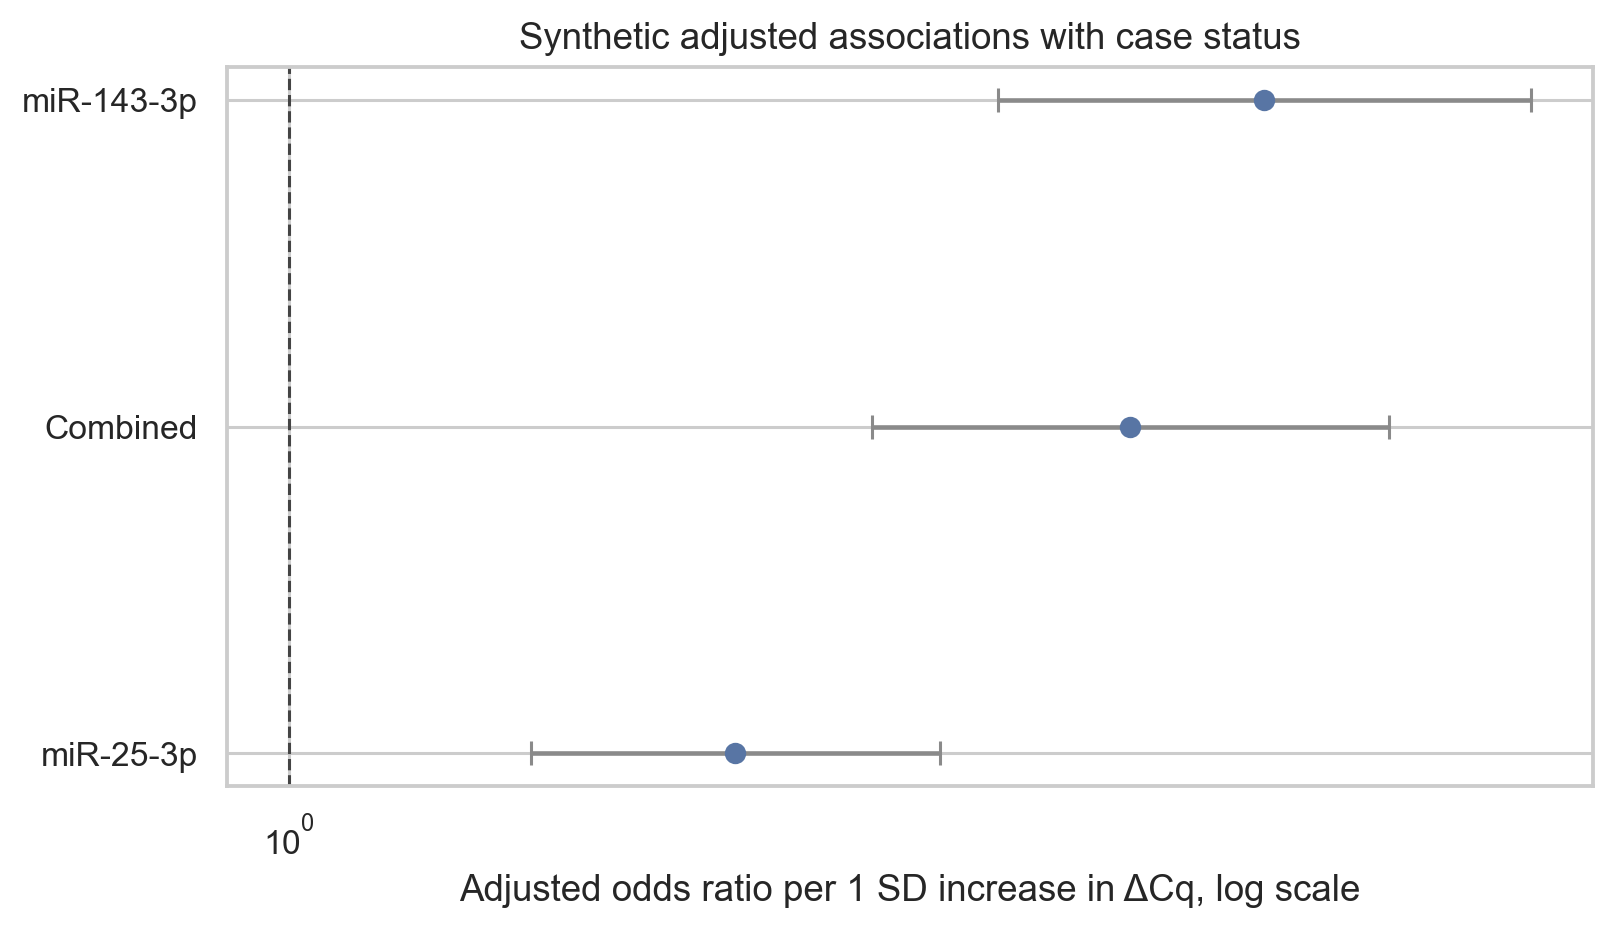

In [19]:
forest_models = adjusted_models.sort_values("adjusted_odds_ratio").reset_index(drop=True)
y_positions = np.arange(len(forest_models))

fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.errorbar(
    forest_models["adjusted_odds_ratio"],
    y_positions,
    xerr=[
        forest_models["adjusted_odds_ratio"] - forest_models["ci_low"],
        forest_models["ci_high"] - forest_models["adjusted_odds_ratio"],
    ],
    fmt="o",
    color="#5875A4",
    ecolor="#8a8a8a",
    capsize=4,
)
ax.axvline(1, color="#444444", linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_yticks(y_positions, forest_models["model"])
ax.set_xlabel("Adjusted odds ratio per 1 SD increase in ΔCq, log scale")
ax.set_title("Synthetic adjusted associations with case status")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03b_synthetic_adjusted_odds_ratios.png", dpi=220, bbox_inches="tight")
plt.close(fig)
display(Image(
    filename=str(FIGURE_DIR / "03b_synthetic_adjusted_odds_ratios.png"),
    alt="Adjusted odds ratios and 95 percent confidence intervals for two synthetic miRNA models and a combined score.",
))

### Model diagnostics

The diagnostics are descriptive checks. The Hosmer-Lemeshow test is included because it often appears in clinical reports, though its result depends on how predictions are grouped. The Brier score adds a direct measure of probabilistic error. Variance inflation factors check the model matrix for strong linear redundancy.

In [20]:
diagnostic_rows = []
for name, fitted in fitted_models.items():
    probabilities = fitted.predict(model_df)
    hl_statistic, hl_p = hosmer_lemeshow(model_df["acne"], probabilities)
    exog = pd.DataFrame(fitted.model.exog, columns=fitted.model.exog_names)
    vif_values = [
        variance_inflation_factor(exog.to_numpy(), i)
        for i, column in enumerate(exog.columns)
        if column != "Intercept"
    ]
    diagnostic_rows.append(
        {
            "model": name,
            "Hosmer_Lemeshow_chi2": hl_statistic,
            "Hosmer_Lemeshow_p": hl_p,
            "Brier_score": brier_score_loss(model_df["acne"], probabilities),
            "maximum_VIF": max(vif_values),
        }
    )

model_diagnostics = pd.DataFrame(diagnostic_rows)
model_diagnostics.to_csv(TABLE_DIR / "08b_model_diagnostics.csv", index=False)
model_diagnostics

,model,Hosmer_Lemeshow_chi2,Hosmer_Lemeshow_p,Brier_score,maximum_VIF
0,miR-25-3p,8.986,0.344,0.214,1.022
1,miR-143-3p,6.018,0.645,0.189,1.015
2,Combined,7.190,0.516,0.193,1.019


## Cross-validated discrimination

ROC performance is estimated from out-of-fold predictions using stratified five-fold cross-validation. This is more honest than fitting and evaluating a model on the same rows. It is still an internal estimate from synthetic data, not clinical validation.

In [21]:
feature_sets = {
    "miR-25-3p": ["dcq_25"],
    "miR-143-3p": ["dcq_143"],
    "Two-miRNA score": ["dcq_25", "dcq_143"],
    "Adjusted two-miRNA model": [
        "dcq_25", "dcq_143", "age", "sex_female", "bmi", "smoke"
    ],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
y = model_df["acne"].to_numpy()
roc_rows = []
oof_predictions = {}

for name, features in feature_sets.items():
    estimator = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, random_state=SEED)),
        ]
    )
    probabilities = cross_val_predict(
        estimator,
        model_df[features],
        y,
        cv=cv,
        method="predict_proba",
    )[:, 1]
    oof_predictions[name] = probabilities
    auc = roc_auc_score(y, probabilities)
    ci_low, ci_high = bootstrap_auc(y, probabilities)
    operating_point = threshold_metrics(y, probabilities)
    roc_rows.append(
        {
            "model": name,
            "cross_validated_AUC": auc,
            "ci_low": ci_low,
            "ci_high": ci_high,
            **operating_point,
        }
    )

roc_results = pd.DataFrame(roc_rows)
roc_results.to_csv(TABLE_DIR / "09_cross_validated_roc.csv", index=False)
roc_results

,model,cross_validated_AUC,ci_low,ci_high,cutoff,sensitivity,specificity,PPV,NPV,accuracy
0,miR-25-3p,0.718,0.660,0.778,0.543,0.722,0.657,0.730,0.648,0.694
1,miR-143-3p,0.773,0.718,0.824,0.604,0.667,0.800,0.811,0.651,0.725
2,Two-miRNA score,0.770,0.715,0.820,0.578,0.700,0.764,0.792,0.665,0.728
3,Adjusted two-miRNA model,0.763,0.712,0.813,0.544,0.744,0.671,0.744,0.671,0.713


### Paired AUC comparison

The two-marker score and miR-143-3p use predictions for the same synthetic records. Their AUC difference is resampled as a pair. This preserves the dependence between the two curves.

In [22]:
score_a = oof_predictions["Two-miRNA score"]
score_b = oof_predictions["miR-143-3p"]
observed_auc_difference = roc_auc_score(y, score_a) - roc_auc_score(y, score_b)

local_rng = np.random.default_rng(SEED)
auc_differences = []
for _ in range(2000):
    idx = local_rng.integers(0, len(y), len(y))
    if len(np.unique(y[idx])) < 2:
        continue
    auc_differences.append(
        roc_auc_score(y[idx], score_a[idx]) - roc_auc_score(y[idx], score_b[idx])
    )

auc_ci_low, auc_ci_high = np.quantile(auc_differences, [0.025, 0.975])
left_tail = np.mean(np.asarray(auc_differences) <= 0)
right_tail = np.mean(np.asarray(auc_differences) >= 0)
auc_p_value = min(1.0, 2 * min(left_tail, right_tail))

auc_comparison = pd.DataFrame(
    {
        "comparison": ["Two-miRNA score minus miR-143-3p"],
        "AUC_difference": [observed_auc_difference],
        "ci_low": [auc_ci_low],
        "ci_high": [auc_ci_high],
        "paired_bootstrap_p": [auc_p_value],
    }
)
auc_comparison.to_csv(TABLE_DIR / "09b_auc_comparison.csv", index=False)
auc_comparison

,comparison,AUC_difference,ci_low,ci_high,paired_bootstrap_p
0,Two-miRNA score minus miR-143-3p,-0.003,-0.014,0.005,0.612


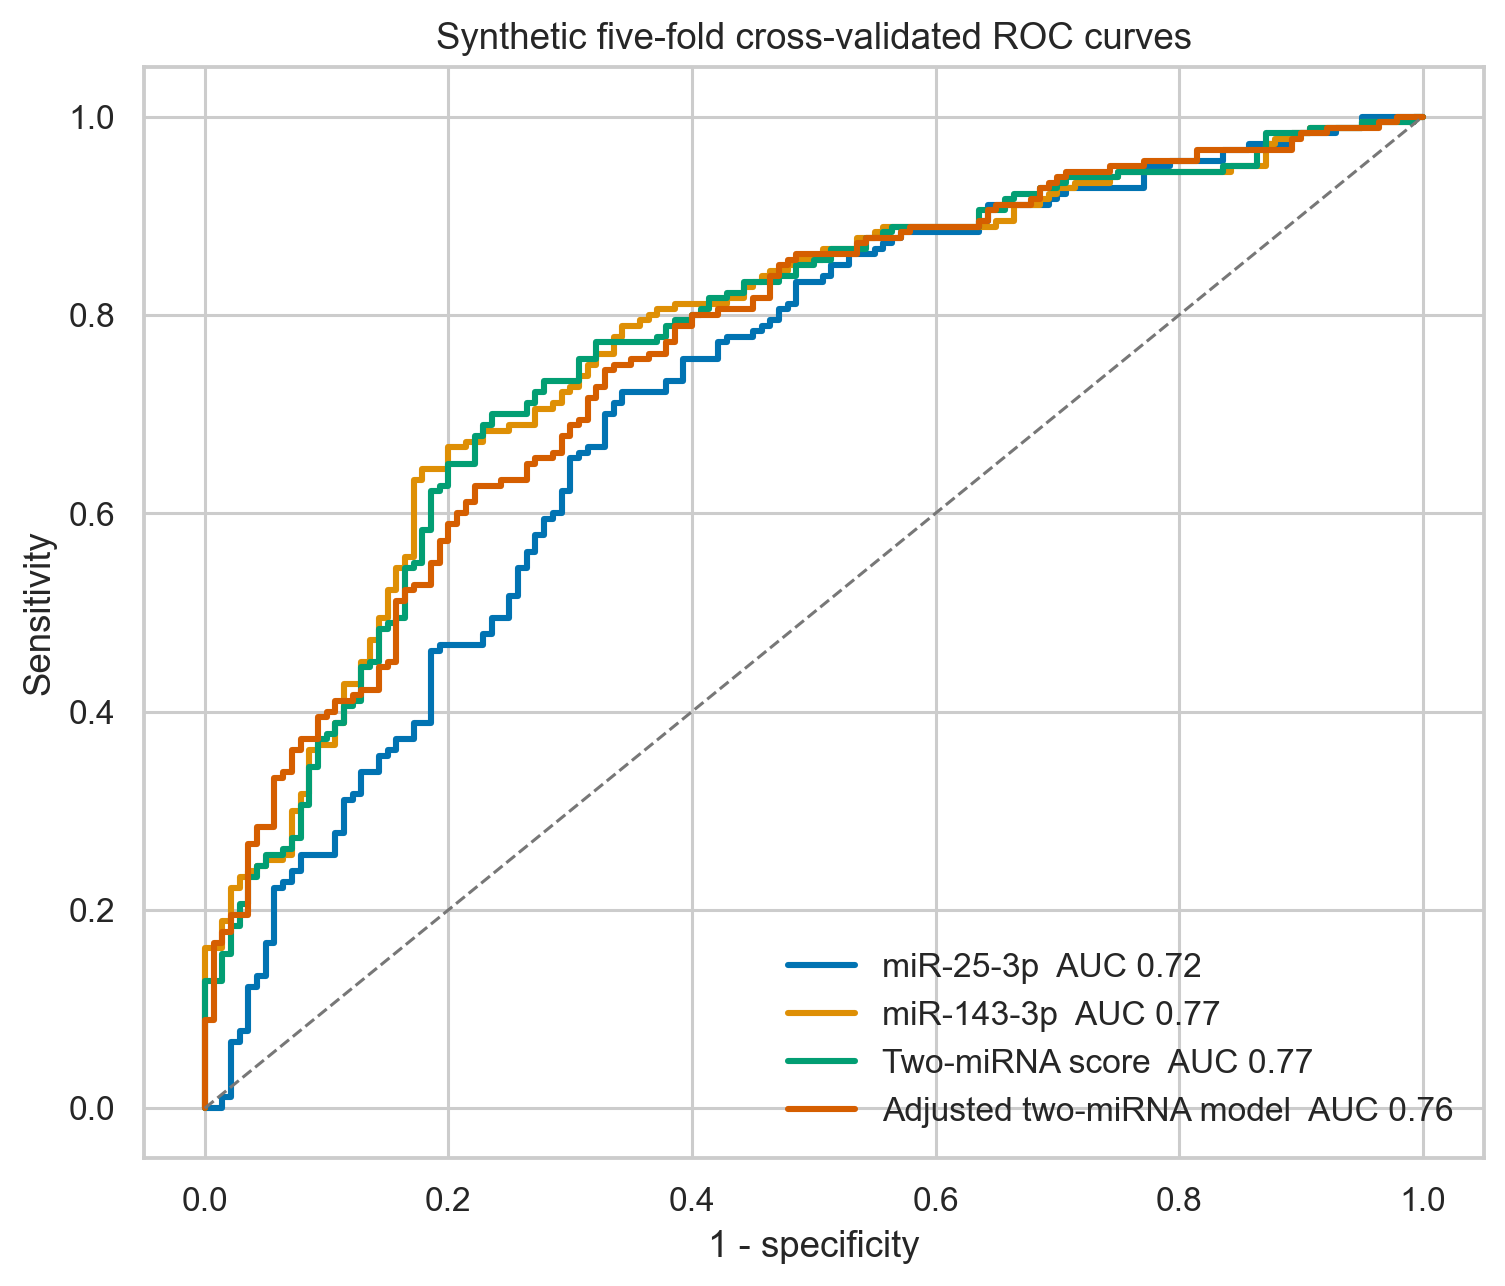

In [23]:
fig, ax = plt.subplots(figsize=(7, 6))
palette = sns.color_palette("colorblind", n_colors=len(oof_predictions))

for color, (name, probabilities) in zip(palette, oof_predictions.items()):
    fpr, tpr, _ = roc_curve(y, probabilities)
    auc = roc_auc_score(y, probabilities)
    ax.plot(fpr, tpr, linewidth=2, color=color, label=f"{name}  AUC {auc:.2f}")

ax.plot([0, 1], [0, 1], linestyle="--", color="#777777", linewidth=1)
ax.set_xlabel("1 - specificity")
ax.set_ylabel("Sensitivity")
ax.set_title("Synthetic five-fold cross-validated ROC curves")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_synthetic_cross_validated_roc.png", dpi=220, bbox_inches="tight")
plt.close(fig)
display(Image(
    filename=str(FIGURE_DIR / "04_synthetic_cross_validated_roc.png"),
    alt="Five-fold cross-validated ROC curves from four synthetic miRNA models.",
))

## Sensitivity analysis

The primary comparison is repeated in the full synthetic cohort, after removing high-Cq QC flags, and among synthetic female records. Stable direction across these scenarios is more useful than one isolated p-value.

In [24]:
sensitivity_scenarios = {
    "Full synthetic cohort": df,
    "QC-pass records": df.loc[df["qc_pass"]],
    "Synthetic female records": df.loc[df["sex_female"].eq(1)],
}

sensitivity_rows = []
for scenario, frame in sensitivity_scenarios.items():
    for variable in ["dcq_25", "dcq_143"]:
        result = compare_groups(frame, variable)
        sensitivity_rows.append(
            {
                "scenario": scenario,
                "marker": variable,
                "median_difference": result["median_difference"],
                "rank_biserial_r": result["rank_biserial_r"],
                "p_value": result["p_value"],
                "n_acne": result["n_acne"],
                "n_control": result["n_control"],
            }
        )

sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity.to_csv(TABLE_DIR / "10_sensitivity.csv", index=False)
sensitivity

,scenario,marker,median_difference,rank_biserial_r,p_value,n_acne,n_control
0,Full synthetic cohort,dcq_25,1.012,0.435,0.000,180,140
1,Full synthetic cohort,dcq_143,1.214,0.547,0.000,180,140
2,QC-pass records,dcq_25,1.020,0.460,0.000,174,138
3,QC-pass records,dcq_143,1.158,0.532,0.000,174,138
4,Synthetic female records,dcq_25,1.084,0.432,0.000,117,103
5,Synthetic female records,dcq_143,1.399,0.593,0.000,117,103


## miRNA co-expression

The two Spearman correlations are calculated separately. Their direct difference is `rho_acne - rho_control`.

The confidence interval resamples each group independently. The p-value comes from permuting group labels while keeping each person's paired miRNA measurements together. This avoids calling a transformed Fisher-z difference `Δrho`.

In [25]:
coexpression_df = df.loc[df["qc_pass"], ["group", "dcq_25", "dcq_143"]].dropna()

def spearman_for_group(frame):
    return stats.spearmanr(frame["dcq_25"], frame["dcq_143"]).statistic


rho_acne = spearman_for_group(coexpression_df.loc[coexpression_df.group.eq("acne")])
rho_control = spearman_for_group(coexpression_df.loc[coexpression_df.group.eq("control")])
observed_difference = rho_acne - rho_control

local_rng = np.random.default_rng(SEED)
boot_differences = []
acne_pairs = coexpression_df.loc[coexpression_df.group.eq("acne")].reset_index(drop=True)
control_pairs = coexpression_df.loc[coexpression_df.group.eq("control")].reset_index(drop=True)
for _ in range(1500):
    acne_boot = acne_pairs.iloc[local_rng.integers(0, len(acne_pairs), len(acne_pairs))]
    control_boot = control_pairs.iloc[local_rng.integers(0, len(control_pairs), len(control_pairs))]
    boot_differences.append(spearman_for_group(acne_boot) - spearman_for_group(control_boot))
ci_low, ci_high = np.quantile(boot_differences, [0.025, 0.975])

pairs = coexpression_df[["dcq_25", "dcq_143"]].reset_index(drop=True)
labels = coexpression_df["group"].to_numpy().copy()
permuted_differences = []
for _ in range(2000):
    shuffled = local_rng.permutation(labels)
    acne_perm = pairs.loc[shuffled == "acne"]
    control_perm = pairs.loc[shuffled == "control"]
    permuted_differences.append(spearman_for_group(acne_perm) - spearman_for_group(control_perm))
p_value = (np.sum(np.abs(permuted_differences) >= abs(observed_difference)) + 1) / (
    len(permuted_differences) + 1
)

coexpression_results = pd.DataFrame(
    {
        "quantity": ["rho_acne", "rho_control", "direct_rho_difference", "permutation_p"],
        "estimate": [rho_acne, rho_control, observed_difference, p_value],
        "ci_low": [np.nan, np.nan, ci_low, np.nan],
        "ci_high": [np.nan, np.nan, ci_high, np.nan],
    }
)
coexpression_results.to_csv(TABLE_DIR / "11_coexpression.csv", index=False)
coexpression_results

,quantity,estimate,ci_low,ci_high
0,rho_acne,0.618,NaN,NaN
1,rho_control,0.582,NaN,NaN
2,direct_rho_difference,0.036,-0.124,0.198
3,permutation_p,0.584,NaN,NaN


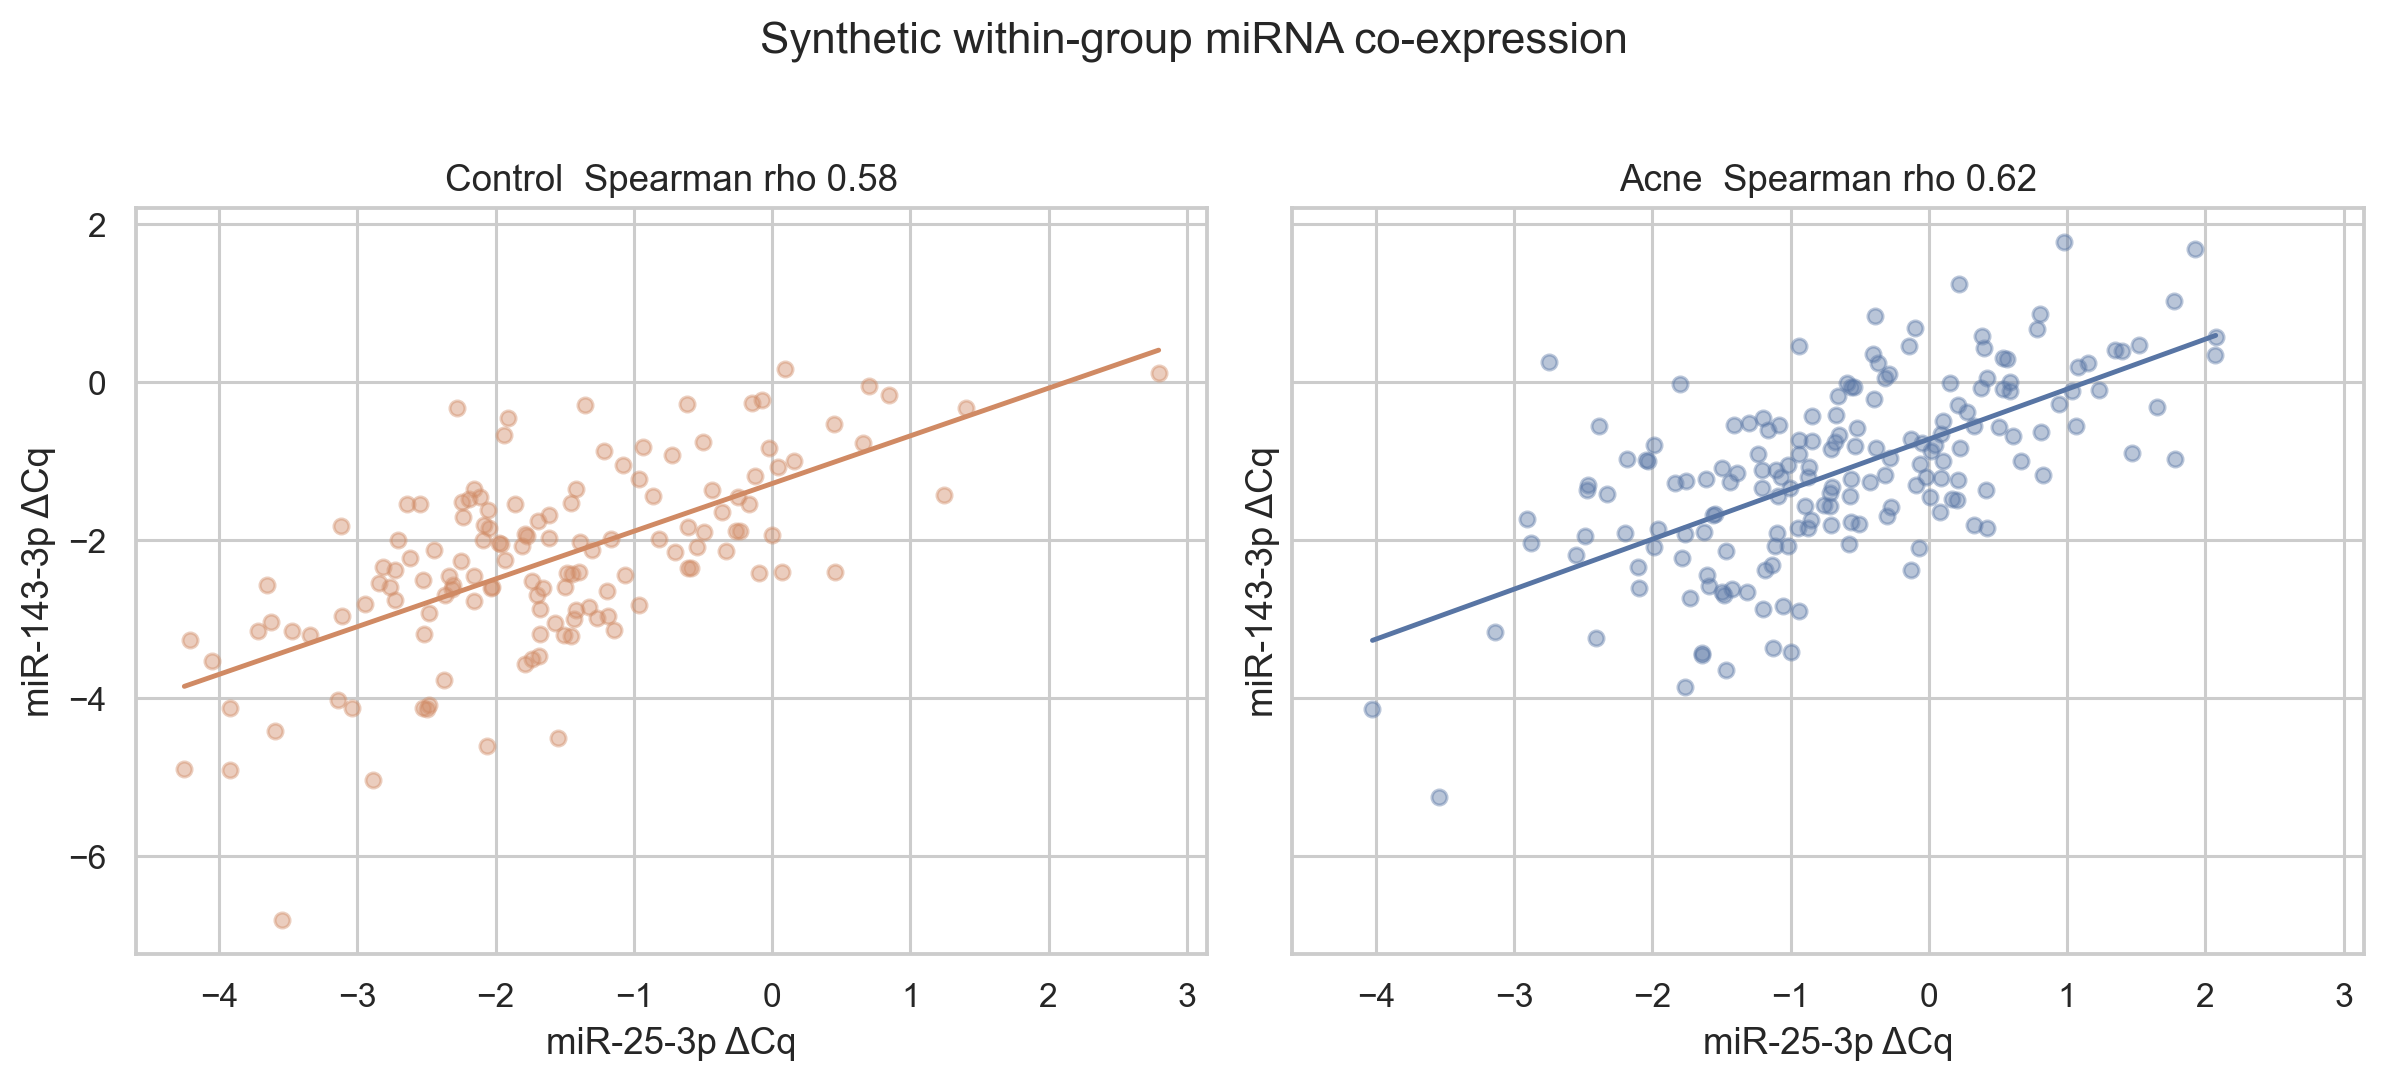

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharex=True, sharey=True)
for ax, group, color, rho in [
    (axes[0], "control", "#D08A64", rho_control),
    (axes[1], "acne", "#5875A4", rho_acne),
]:
    subset = coexpression_df.loc[coexpression_df["group"].eq(group)]
    sns.regplot(
        data=subset,
        x="dcq_25",
        y="dcq_143",
        scatter_kws={"alpha": 0.42, "s": 24},
        line_kws={"linewidth": 1.6},
        color=color,
        ci=None,
        ax=ax,
    )
    ax.set_title(f"{group.capitalize()}  Spearman rho {rho:.2f}")
    ax.set_xlabel("miR-25-3p ΔCq")
    ax.set_ylabel("miR-143-3p ΔCq")

fig.suptitle("Synthetic within-group miRNA co-expression", y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "05_synthetic_coexpression.png", dpi=220, bbox_inches="tight")
plt.close(fig)
display(Image(
    filename=str(FIGURE_DIR / "05_synthetic_coexpression.png"),
    alt="Scatter plots of synthetic miR-25-3p and miR-143-3p delta Cq values in control and acne groups.",
))

## Prospective power planning

Observed post-hoc power is not used as evidence that a result is reliable. This section instead shows approximate sample sizes for a future two-group study under a range of standardized effect sizes. The calculation assumes equal groups and a two-sided independent t test. A real study would need assay-specific variance estimates, attrition allowance, and a prespecified primary endpoint.

In [27]:
power_model = TTestIndPower()
planning_rows = []
for effect_size in [0.30, 0.50, 0.70]:
    n_per_group = power_model.solve_power(
        effect_size=effect_size,
        alpha=0.05,
        power=0.80,
        ratio=1.0,
        alternative="two-sided",
    )
    planning_rows.append(
        {
            "standardized_effect_size": effect_size,
            "target_power": 0.80,
            "alpha": 0.05,
            "approximate_n_per_group": int(np.ceil(n_per_group)),
        }
    )

power_plan = pd.DataFrame(planning_rows)
power_plan.to_csv(TABLE_DIR / "12_prospective_power_plan.csv", index=False)
power_plan

,standardized_effect_size,target_power,alpha,approximate_n_per_group
0,0.300,0.800,0.050,176
1,0.500,0.800,0.050,64
2,0.700,0.800,0.050,34


## Export blog-ready figures and tables

The analysis outputs are copied into five post folders. Each table is also rendered as a PNG so the same result can be used in a blog editor without rebuilding the layout by hand. The CSV files remain the source of record.

In [28]:
BLOG_DIR = PROJECT_ROOT / "blog-series"
for part_number in range(1, 6):
    for asset_type in ["figures", "tables"]:
        (BLOG_DIR / f"part-{part_number}" / asset_type).mkdir(parents=True, exist_ok=True)


def p_for_table(value):
    if pd.isna(value):
        return "NA"
    return "<0.001" if value < 0.001 else f"{value:.3f}"


def number_for_table(value, digits=2):
    return "NA" if pd.isna(value) else f"{value:.{digits}f}"


def render_table_png(frame, destination, title, note="Synthetic data for demonstration only"):
    shown = frame.copy().fillna("NA").astype(str)
    rows, columns = shown.shape
    figure_width = min(22, max(8.5, 1.75 * columns))
    figure_height = max(3.0, 1.75 + 0.48 * rows)
    fig, ax = plt.subplots(figsize=(figure_width, figure_height))
    ax.axis("off")
    table = ax.table(
        cellText=shown.values,
        colLabels=shown.columns,
        cellLoc="left",
        colLoc="left",
        bbox=[0, 0.12, 1, 0.76],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8.5)
    for (row, column), cell in table.get_celld().items():
        cell.set_edgecolor("#D8DEE9")
        if row == 0:
            cell.set_facecolor("#E8EEF7")
            cell.set_text_props(weight="bold", color="#172033")
        elif row % 2 == 0:
            cell.set_facecolor("#F7F9FC")
        else:
            cell.set_facecolor("#FFFFFF")
    ax.set_title(title, loc="left", fontsize=14, fontweight="bold", pad=14, color="#172033")
    fig.text(0.01, 0.035, note, ha="left", va="bottom", fontsize=8.5, color="#5D6470")
    fig.savefig(destination, dpi=220, bbox_inches="tight", facecolor="white")
    plt.close(fig)


table_01 = demographics.rename(
    columns={"variable": "Measure", "acne": "Acne", "control": "Control", "test": "Test", "p_value": "p"}
)
table_01["p"] = demographics["p_value"].map(p_for_table)

table_02 = clinical_profile.rename(columns={"measure": "Measure", "synthetic_summary": "Synthetic acne group"})

table_03 = reference_checks.rename(
    columns={"reference": "Reference", "acne": "Acne", "control": "Control", "rank_biserial_r": "Rank-biserial r", "p_value": "p"}
)
table_03["Rank-biserial r"] = reference_checks["rank_biserial_r"].map(lambda x: number_for_table(x, 3))
table_03["p"] = reference_checks["p_value"].map(p_for_table)

table_04 = primary[[
    "variable", "acne", "control", "median_difference", "difference_ci_low", "difference_ci_high",
    "rank_biserial_r", "p_value", "q_value", "relative_expression_ratio"
]].copy()
table_04["variable"] = table_04["variable"].map({"dcq_25": "miR-25-3p", "dcq_143": "miR-143-3p"})
table_04["Median difference\n(95% CI)"] = table_04.apply(
    lambda row: f"{row['median_difference']:.2f} ({row['difference_ci_low']:.2f} to {row['difference_ci_high']:.2f})", axis=1
)
table_04["Rank-biserial r"] = table_04["rank_biserial_r"].map(lambda x: number_for_table(x, 3))
table_04["p"] = table_04["p_value"].map(p_for_table)
table_04["q"] = table_04["q_value"].map(p_for_table)
table_04["Expression ratio\nacne/control"] = table_04["relative_expression_ratio"].map(lambda x: number_for_table(x, 3))
table_04 = table_04[["variable", "acne", "control", "Median difference\n(95% CI)", "Rank-biserial r", "p", "q", "Expression ratio\nacne/control"]]
table_04.columns = ["Marker", "Acne ΔCq", "Control ΔCq", "Median difference\n(95% CI)", "Rank-biserial r", "p", "q", "Expression ratio\nacne/control"]

table_05 = normalization.rename(
    columns={"approach": "Approach", "marker": "Marker", "acne": "Acne", "control": "Control", "rank_biserial_r": "Rank-biserial r", "p_value": "p", "q_within_approach": "q within approach"}
)
table_05["Rank-biserial r"] = normalization["rank_biserial_r"].map(lambda x: number_for_table(x, 3))
table_05["p"] = normalization["p_value"].map(p_for_table)
table_05["q within approach"] = normalization["q_within_approach"].map(p_for_table)
table_05["Approach"] = table_05["Approach"].replace(
    {"Stable reference ΔCq": "Stable reference\nΔCq", "Unstable reference ΔCq": "Unstable reference\nΔCq"}
)

table_06 = clinical_correlations.copy()
table_06["marker"] = table_06["marker"].map({"dcq_25": "miR-25-3p", "dcq_143": "miR-143-3p"})
table_06["clinical_variable"] = table_06["clinical_variable"].str.replace("_", " ").str.title()
table_06["spearman_rho"] = table_06["spearman_rho"].map(lambda x: number_for_table(x, 3))
table_06["p_value"] = clinical_correlations["p_value"].map(p_for_table)
table_06["q_value"] = clinical_correlations["q_value"].map(p_for_table)
table_06.columns = ["Marker", "Clinical variable", "Spearman rho", "p", "n", "q"]
table_06 = table_06[["Marker", "Clinical variable", "Spearman rho", "p", "q", "n"]]

table_07 = subgroups.copy()
table_07["subgroup"] = table_07["subgroup"].str.replace("_", " ").str.title()
table_07["marker"] = table_07["marker"].map({"dcq_25": "miR-25-3p", "dcq_143": "miR-143-3p"})
table_07["Effect (95% CI)"] = table_07.apply(
    lambda row: f"{row['rank_biserial_r']:.2f} ({row['ci_low']:.2f} to {row['ci_high']:.2f})", axis=1
)
table_07["p"] = subgroups["p_value"].map(p_for_table)
table_07["q"] = subgroups["q_value"].map(p_for_table)
table_07 = table_07[["subgroup", "marker", "n_present", "n_absent", "Effect (95% CI)", "p", "q"]]
table_07.columns = ["Subgroup", "Marker", "Present n", "Absent n", "Rank-biserial r\n(95% CI)", "p", "q"]

table_08 = adjusted_models.copy()
table_08["Adjusted OR (95% CI)"] = table_08.apply(
    lambda row: f"{row['adjusted_odds_ratio']:.2f} ({row['ci_low']:.2f} to {row['ci_high']:.2f})", axis=1
)
table_08["p"] = adjusted_models["p_value"].map(p_for_table)
table_08["AIC"] = adjusted_models["AIC"].map(lambda x: number_for_table(x, 1))
table_08 = table_08[["model", "Adjusted OR (95% CI)", "p", "AIC"]]
table_08.columns = ["Model", "Adjusted OR per 1 SD ΔCq\n(95% CI)", "p", "AIC"]

table_09 = model_diagnostics.copy()
for column in ["Hosmer_Lemeshow_chi2", "Brier_score", "maximum_VIF"]:
    table_09[column] = model_diagnostics[column].map(lambda x: number_for_table(x, 3))
table_09["Hosmer_Lemeshow_p"] = model_diagnostics["Hosmer_Lemeshow_p"].map(p_for_table)
table_09.columns = ["Model", "HL chi-square", "HL p", "Brier score", "Maximum VIF"]

table_10 = roc_results.copy()
table_10["model"] = table_10["model"].replace({"Adjusted two-miRNA model": "Adjusted two-miRNA"})
for column in ["cross_validated_AUC", "ci_low", "ci_high", "cutoff", "sensitivity", "specificity", "PPV", "NPV", "accuracy"]:
    table_10[column] = roc_results[column].map(lambda x: number_for_table(x, 3))
table_10.columns = ["Model", "CV AUC", "CI low", "CI high", "Cutoff", "Sensitivity", "Specificity", "PPV", "NPV", "Accuracy"]

table_11 = auc_comparison.copy()
for column in ["AUC_difference", "ci_low", "ci_high"]:
    table_11[column] = auc_comparison[column].map(lambda x: number_for_table(x, 3))
table_11["paired_bootstrap_p"] = auc_comparison["paired_bootstrap_p"].map(p_for_table)
table_11.columns = ["Comparison", "AUC difference", "CI low", "CI high", "Paired bootstrap p"]

table_12 = sensitivity.copy()
table_12["marker"] = table_12["marker"].map({"dcq_25": "miR-25-3p", "dcq_143": "miR-143-3p"})
for column in ["median_difference", "rank_biserial_r"]:
    table_12[column] = sensitivity[column].map(lambda x: number_for_table(x, 3))
table_12["p_value"] = sensitivity["p_value"].map(p_for_table)
table_12.columns = ["Scenario", "Marker", "Median difference", "Rank-biserial r", "p", "Acne n", "Control n"]
table_12["Scenario"] = table_12["Scenario"].replace({"Synthetic female records": "Synthetic female\nrecords"})

table_13 = coexpression_results.copy()
table_13["quantity"] = table_13["quantity"].map({
    "rho_acne": "Spearman rho in acne",
    "rho_control": "Spearman rho in control",
    "direct_rho_difference": "Direct rho difference",
    "permutation_p": "Permutation p",
})
for column in ["estimate", "ci_low", "ci_high"]:
    table_13[column] = coexpression_results[column].map(lambda x: number_for_table(x, 3))
table_13.columns = ["Quantity", "Estimate", "CI low", "CI high"]

table_14 = power_plan.copy()
for column in ["standardized_effect_size", "target_power", "alpha"]:
    table_14[column] = power_plan[column].map(lambda x: number_for_table(x, 2))
table_14.columns = ["Standardized effect size", "Target power", "Alpha", "Approximate n per group"]

table_exports = [
    (1, "table-01-synthetic-cohort-characteristics.png", "Table 1. Synthetic cohort characteristics", table_01),
    (1, "table-02-synthetic-clinical-profile.png", "Table 2. Synthetic clinical profile", table_02),
    (2, "table-03-reference-measurement-checks.png", "Table 3. Reference measurement checks", table_03),
    (2, "table-04-primary-delta-cq-results.png", "Table 4. Primary ΔCq results", table_04),
    (2, "table-05-normalization-sensitivity.png", "Table 5. Normalization sensitivity", table_05),
    (3, "table-06-clinical-correlations.png", "Table 6. Clinical correlations", table_06),
    (3, "table-07-subgroup-estimates.png", "Table 7. Exploratory subgroup estimates", table_07),
    (4, "table-08-adjusted-association-models.png", "Table 8. Adjusted association models", table_08),
    (4, "table-09-model-diagnostics.png", "Table 9. Model diagnostics", table_09),
    (4, "table-10-cross-validated-roc.png", "Table 10. Cross-validated ROC results", table_10),
    (4, "table-11-paired-auc-comparison.png", "Table 11. Paired AUC comparison", table_11),
    (5, "table-12-sensitivity-analysis.png", "Table 12. Sensitivity analysis", table_12),
    (5, "table-13-coexpression-comparison.png", "Table 13. Co-expression comparison", table_13),
    (5, "table-14-prospective-power-plan.png", "Table 14. Prospective power plan", table_14),
]

manifest_rows = []
for part_number, filename, title, frame in table_exports:
    destination = BLOG_DIR / f"part-{part_number}" / "tables" / filename
    render_table_png(frame, destination, title)
    manifest_rows.append({"part": part_number, "type": "table", "file": str(destination.relative_to(BLOG_DIR)), "title": title})

figure_exports = [
    (1, PROJECT_ROOT / "assets" / "analysis-workflow.svg", "figure-01-analysis-workflow.svg", "Figure 1. Analysis workflow"),
    (1, FIGURE_DIR / "00_synthetic_demographic_balance.png", "figure-02-synthetic-cohort-characteristics.png", "Figure 2. Synthetic cohort characteristics"),
    (1, FIGURE_DIR / "00b_synthetic_clinical_profile.png", "figure-03-synthetic-clinical-profile.png", "Figure 3. Synthetic clinical profile"),
    (2, FIGURE_DIR / "01_synthetic_primary_expression.png", "figure-04-primary-delta-cq-comparison.png", "Figure 4. Primary ΔCq comparison"),
    (2, FIGURE_DIR / "01b_synthetic_normalization_sensitivity.png", "figure-05-normalization-sensitivity.png", "Figure 5. Normalization sensitivity"),
    (3, FIGURE_DIR / "02_synthetic_clinical_correlations.png", "figure-06-clinical-correlations.png", "Figure 6. Clinical correlations"),
    (3, FIGURE_DIR / "03_synthetic_subgroup_forest.png", "figure-07-subgroup-estimates.png", "Figure 7. Exploratory subgroup estimates"),
    (4, FIGURE_DIR / "03b_synthetic_adjusted_odds_ratios.png", "figure-08-adjusted-odds-ratios.png", "Figure 8. Adjusted odds ratios"),
    (4, FIGURE_DIR / "04_synthetic_cross_validated_roc.png", "figure-09-cross-validated-roc.png", "Figure 9. Cross-validated ROC curves"),
    (5, FIGURE_DIR / "05_synthetic_coexpression.png", "figure-10-coexpression.png", "Figure 10. Within-group miRNA co-expression"),
]

for part_number, source, filename, title in figure_exports:
    destination = BLOG_DIR / f"part-{part_number}" / "figures" / filename
    shutil.copy2(source, destination)
    manifest_rows.append({"part": part_number, "type": "figure", "file": str(destination.relative_to(BLOG_DIR)), "title": title})

asset_manifest = pd.DataFrame(manifest_rows).sort_values(["part", "type", "file"])
asset_manifest.to_csv(BLOG_DIR / "asset-manifest.csv", index=False)

print(f"Exported {len(table_exports)} tables and {len(figure_exports)} figures for the blog series")
asset_manifest

Exported 14 tables and 10 figures for the blog series


,part,type,file,title
14,1,figure,part-1/figures/figure-01-analysis-workflow.svg,Figure 1. Analysis workflow
15,1,figure,part-1/figures/figure-02-synthetic-cohort-char...,Figure 2. Synthetic cohort characteristics
16,1,figure,part-1/figures/figure-03-synthetic-clinical-pr...,Figure 3. Synthetic clinical profile
0,1,table,part-1/tables/table-01-synthetic-cohort-charac...,Table 1. Synthetic cohort characteristics
1,1,table,part-1/tables/table-02-synthetic-clinical-prof...,Table 2. Synthetic clinical profile
17,2,figure,part-2/figures/figure-04-primary-delta-cq-comp...,Figure 4. Primary ΔCq comparison
18,2,figure,part-2/figures/figure-05-normalization-sensiti...,Figure 5. Normalization sensitivity
2,2,table,part-2/tables/table-03-reference-measurement-c...,Table 3. Reference measurement checks
3,2,table,part-2/tables/table-04-primary-delta-cq-result...,Table 4. Primary ΔCq results
4,2,table,part-2/tables/table-05-normalization-sensitivi...,Table 5. Normalization sensitivity


## Reproducibility record

The public dataset is generated from code, so anyone can rebuild it. This record captures the seed and package versions used for the executed notebook.

In [29]:
import scipy
import statsmodels
import sklearn
import matplotlib
import seaborn

session = {
    "synthetic_data": True,
    "medical_use": False,
    "seed": SEED,
    "rows": len(df),
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scipy": scipy.__version__,
    "statsmodels": statsmodels.__version__,
    "scikit_learn": sklearn.__version__,
    "matplotlib": matplotlib.__version__,
    "seaborn": seaborn.__version__,
}

with open(PROJECT_ROOT / "session.json", "w", encoding="utf-8") as handle:
    json.dump(session, handle, indent=2)

session

{'synthetic_data': True,
 'medical_use': False,
 'seed': 20260915,
 'rows': 320,
 'python': '3.11.15',
 'numpy': '2.4.3',
 'pandas': '2.3.3',
 'scipy': '1.17.1',
 'statsmodels': '0.14.6',
 'scikit_learn': '1.8.0',
 'matplotlib': '3.10.8',
 'seaborn': '0.13.2'}

## Closing note

This notebook is a methods demonstration. Its useful outcome is the workflow, not the simulated numerical result.

The analysis checks the sign of ΔCq, tests the reference measurement, separates primary and exploratory questions, reports uncertainty, avoids causal wording, evaluates ROC performance out of fold, and compares correlations on the correct scale.

No result in this notebook should be cited as evidence about acne vulgaris or any miRNA.